## Imports

In [89]:
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime
import time
import os        # To check if files exist
from tqdm.notebook import tqdm # To show a progress bar in the notebook

## Constants and Game IDs

In [90]:
# --- Constants ---
BASE_URL = "https://api-web.nhle.com/v1/gamecenter/"
SEASON = "2023"
GAME_TYPE = "02"  # 01 = Preseason, 02 = Regular Season, 03 = Playoffs
NUM_GAMES = 1312
DATA_FILE_NAME = "nhl_raw_plays.parquet" # Parquet is faster and smaller than CSV

# --- Generate all game IDs ---
# This creates a list of strings like ["2023020001", "2023020002", ..., "2023021312"]
game_ids = [f"{SEASON}{GAME_TYPE}{str(i).zfill(4)}" for i in range(1, NUM_GAMES + 1)]

print(f"Generated {len(game_ids)} game IDs.")
print(f"First ID: {game_ids[0]}, Last ID: {game_ids[-1]}")

Generated 1312 game IDs.
First ID: 2023020001, Last ID: 2023021312


## Data Retrieval

In [91]:
def getGameData(game_id):

# Fetches play-by-play data for a given game ID

    # Create URL
    url = f"{BASE_URL}{game_id}/play-by-play"

    try:
        # Call the API
        response = requests.get(url)
        response.raise_for_status() # Raise an exception for bad status codes

        # Extract JSON data
        data = response.json()
        plays = data.get("plays", [])
        return plays

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for game {game_id}: {e}")
        return None # return None if there's an error

In [92]:
all_plays_data = []

# Check if data file exists
if not os.path.exists(DATA_FILE_NAME):
    print(f"Data file {DATA_FILE_NAME} does not exist. Starting data collection...")

    # Loop through all game IDs with progress bar
    for game_id in tqdm(game_ids, desc="Fetching data"):
        plays = getGameData(game_id)

        # Add plays to all_plays_data
        if plays:
            all_plays_data.extend(plays)

    print(f"\nTotal plays collected: {len(all_plays_data)}")

    # Convert to DataFrame
    df = pd.DataFrame(all_plays_data)
    
    # Save to Parquet file
    df.to_parquet(DATA_FILE_NAME, index=False)
    print(f"Data saved to {DATA_FILE_NAME}")
else:
    print(f"Loading data from {DATA_FILE_NAME}...")
    df = pd.read_parquet(DATA_FILE_NAME)
    print(f"Loaded {len(df)} plays from {DATA_FILE_NAME}")
    
# Display first few rows of the DataFrame
print(f"\nDataFrame shape: {df.shape}")
df.head()

Loading data from nhl_raw_plays.parquet...
Loaded 413676 plays from nhl_raw_plays.parquet

DataFrame shape: (413676, 11)


,eventId,periodDescriptor,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,details,pptReplayUrl
0,102,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",00:00,20:00,1551,left,520,period-start,8,None,None
1,101,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",00:00,20:00,1551,left,502,faceoff,9,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
2,8,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",00:35,19:25,1551,left,516,stoppage,15,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
3,103,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",00:35,19:25,1551,left,502,faceoff,17,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
4,9,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",00:48,19:12,1551,left,503,hit,20,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None


## Data Cleaning

1. Filter DataFrame for shots
2. Flatten Nested columns (period and details)

In [93]:
# identify all unique events in the data
df["typeDescKey"].unique()

array(['period-start', 'faceoff', 'stoppage', 'hit', 'giveaway',
       'shot-on-goal', 'takeaway', 'missed-shot', 'blocked-shot', 'goal',
       'penalty', 'delayed-penalty', 'period-end', 'game-end',
       'shootout-complete', 'failed-shot-attempt'], dtype=object)

In [94]:
# print original shape of df
print(f"Original shape of df: {df.shape}")
# create list of events that we care about from json data
shot_events = ['shot-on-goal', 'missed-shot', 'blocked-shot', 'goal']

# create new dataframe with only the shot events
df_shots = df[df["typeDescKey"].isin(shot_events)].copy()

# print new shafe of df_shots
print(f"New shape of df_shots: {df_shots.shape}")
df_shots.head()

Original shape of df: (413676, 11)
New shape of df_shots: (160123, 11)


,eventId,periodDescriptor,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,details,pptReplayUrl
6,63,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",01:01,18:59,1551,left,506,shot-on-goal,22,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
7,151,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",01:10,18:50,1551,left,506,shot-on-goal,23,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
9,70,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",01:47,18:13,1551,left,506,shot-on-goal,31,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
16,152,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",02:57,17:03,1551,left,506,shot-on-goal,48,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None
18,95,"{'maxRegulationPeriods': 3, 'number': 1, 'peri...",03:51,16:09,1551,left,507,missed-shot,60,"{'assist1PlayerId': None, 'assist1PlayerTotal'...",None


In [95]:
# flatten nested columns

# flatten the details column
df_details_flat = pd.json_normalize(df_shots["details"])

# flatten the period column
df_period_flat = pd.json_normalize(df_shots["periodDescriptor"])

# reset indices of dataframes to ensure they can join correctly
df_shots.reset_index(drop=True, inplace=True)
df_details_flat.reset_index(drop=True, inplace=True)
df_period_flat.reset_index(drop=True, inplace=True)

# join the flattened columns with the original dataframe
df_shots_clean = pd.concat([df_shots, df_details_flat, df_period_flat], axis=1)

# drop the original nested columns
df_shots_clean.drop(columns=["details", "periodDescriptor"], inplace=True)

# rename the 'number' column (from periodDescriptor) to 'period'
df_shots_clean.rename(columns={"number": "period"}, inplace=True)

print(f"Shape after flattening: {df_shots_clean.shape}")
for col in df_shots_clean.columns:
    print(col)
df_shots_clean.head()

Shape after flattening: (160123, 49)
eventId
timeInPeriod
timeRemaining
situationCode
homeTeamDefendingSide
typeCode
typeDescKey
sortOrder
pptReplayUrl
assist1PlayerId
assist1PlayerTotal
assist2PlayerId
assist2PlayerTotal
awaySOG
awayScore
blockingPlayerId
committedByPlayerId
descKey
discreteClip
discreteClipFr
drawnByPlayerId
duration
eventOwnerTeamId
goalieInNetId
highlightClip
highlightClipFr
highlightClipSharingUrl
highlightClipSharingUrlFr
hitteePlayerId
hittingPlayerId
homeSOG
homeScore
losingPlayerId
playerId
reason
scoringPlayerId
scoringPlayerTotal
secondaryReason
servedByPlayerId
shootingPlayerId
shotType
typeCode
winningPlayerId
xCoord
yCoord
zoneCode
maxRegulationPeriods
period
periodType


,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,pptReplayUrl,assist1PlayerId,...,shootingPlayerId,shotType,typeCode,winningPlayerId,xCoord,yCoord,zoneCode,maxRegulationPeriods,period,periodType
0,63,01:01,18:59,1551,left,506,shot-on-goal,22,None,NaN,...,8478178.0,wrist,None,None,58.0,-25.0,O,3,1,REG
1,151,01:10,18:50,1551,left,506,shot-on-goal,23,None,NaN,...,8478010.0,tip-in,None,None,81.0,8.0,O,3,1,REG
2,70,01:47,18:13,1551,left,506,shot-on-goal,31,None,NaN,...,8479661.0,snap,None,None,55.0,30.0,O,3,1,REG
3,152,02:57,17:03,1551,left,506,shot-on-goal,48,None,NaN,...,8479591.0,wrist,None,None,58.0,-30.0,O,3,1,REG
4,95,03:51,16:09,1551,left,507,missed-shot,60,None,NaN,...,8476887.0,wrist,None,None,-63.0,33.0,O,3,1,REG


In [96]:
# remove some unneccesary clip/url columns
df_shots_clean.drop(columns=["highlightClipSharingUrl", "highlightClip", "highlightClipSharingUrlFr",
 "highlightClipFr", "discreteClip", "discreteClipFr", "pptReplayUrl"], inplace = True)

df_shots_clean.head()

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,assist1PlayerId,assist1PlayerTotal,...,shootingPlayerId,shotType,typeCode,winningPlayerId,xCoord,yCoord,zoneCode,maxRegulationPeriods,period,periodType
0,63,01:01,18:59,1551,left,506,shot-on-goal,22,NaN,NaN,...,8478178.0,wrist,None,None,58.0,-25.0,O,3,1,REG
1,151,01:10,18:50,1551,left,506,shot-on-goal,23,NaN,NaN,...,8478010.0,tip-in,None,None,81.0,8.0,O,3,1,REG
2,70,01:47,18:13,1551,left,506,shot-on-goal,31,NaN,NaN,...,8479661.0,snap,None,None,55.0,30.0,O,3,1,REG
3,152,02:57,17:03,1551,left,506,shot-on-goal,48,NaN,NaN,...,8479591.0,wrist,None,None,58.0,-30.0,O,3,1,REG
4,95,03:51,16:09,1551,left,507,missed-shot,60,NaN,NaN,...,8476887.0,wrist,None,None,-63.0,33.0,O,3,1,REG


In [97]:
# Drop columns not relevant for shot analysis
columns_to_drop = [
    # Faceoff-related
    'winningPlayerId',
    'losingPlayerId',
    # Penalty-related
    'committedByPlayerId',
    'drawnByPlayerId',
    'servedByPlayerId',
    'reason',
    'secondaryReason',
    'duration',
    # Hit-Related
    'hittingPlayerId',
    'hitteePlayerId',
    # Other
    'playerId', # Generic column - we will use shootingPlayerId instead
    'descKey', # Redundant because we already have typeDescKey
    'maxRegulationPeriods', # All NHL games have the same number regulation periods
]

df_shots_clean.drop(columns=columns_to_drop, inplace=True)

In [98]:
# create is_goal column
df_shots_clean["is_goal"] = np.where(df_shots_clean["typeDescKey"] == "goal", 1, 0)

print("Goal Counts (1=Goal, 0=No Goal):")
print(df_shots_clean["is_goal"].value_counts())

Goal Counts (1=Goal, 0=No Goal):
is_goal
0    151855
1      8268
Name: count, dtype: int64


### Standardize Coordinates

In [99]:
print("Standardizing coordinates...")

# ensure that the x and y coordinates are numeric
df_shots_clean["xCoord"] = pd.to_numeric(df_shots_clean["xCoord"])
df_shots_clean["yCoord"] = pd.to_numeric(df_shots_clean["yCoord"])

# find all shots that were taken at the "negative" net (xCoord < 0)
flip_mask = df_shots_clean["xCoord"] < 0

# for these rows, multiply the xCoord and yCoord by -1
df_shots_clean.loc[flip_mask, "xCoord"] = df_shots_clean.loc[flip_mask, "xCoord"] * -1
df_shots_clean.loc[flip_mask, "yCoord"] = df_shots_clean.loc[flip_mask, "yCoord"] * -1

print("Coordinates Standardized. All shots are now aimed at the positive-x net.")

# check the results
print("\n--- Original Negative-x Shots (Now Flipped) ---")
# find a goal from period 3 (eventId = 740) to see it's flipped
print(df_shots_clean[df_shots_clean["eventId"] == 740][['period', 'xCoord', 'yCoord']])

print("\n--- Original Positive-x Shots (No Change) ---")
# find goal from period 1 (eventId = 154) to see it's unchanged
print(df_shots_clean[df_shots_clean["eventId"] == 154][['period', 'xCoord', 'yCoord']])



Standardizing coordinates...
Coordinates Standardized. All shots are now aimed at the positive-x net.

--- Original Negative-x Shots (Now Flipped) ---
        period  xCoord  yCoord
76           3    81.0    -4.0
470          2    62.0   -26.0
1225         3    73.0   -10.0
3876         2    68.0    20.0
4703         2    60.0   -28.0
...        ...     ...     ...
154117       2    75.0    -2.0
154990       3    54.0    -1.0
156099       2    82.0     1.0
156913       2    76.0    -2.0
157740       3    61.0    20.0

[166 rows x 3 columns]

--- Original Positive-x Shots (No Change) ---
        period  xCoord  yCoord
12           1    50.0   -16.0
157          1    81.0     5.0
1452         2    87.0     5.0
2153         1    54.0    25.0
2387         1    82.0    -2.0
...        ...     ...     ...
158364       1    60.0    34.0
158831       1    73.0    12.0
158954       1    35.0    13.0
159246       1    82.0   -15.0
159366       1    77.0     3.0

[456 rows x 3 columns]


### Missing Data

In [100]:
# check how many rows are missing a 'shotType'
missing_shots = df_shots_clean["shotType"].isnull().sum()
print(f"Number of missing shotTypes: {missing_shots}")

Number of missing shotTypes: 44691


In [101]:
# fill missing ('NaN') values with the string 'unknown'
df_shots_clean["shotType"].fillna("unknown", inplace=True)

print("Filled missing shot types with 'unknown'")

# check value counts again
print("\nValue counts of shotType:")
print(df_shots_clean["shotType"].value_counts())

Filled missing shot types with 'unknown'

Value counts of shotType:
shotType
wrist           63244
unknown         44691
snap            16062
slap            13554
tip-in          10102
backhand         8284
deflected        2327
wrap-around       907
poke              434
bat               429
between-legs       80
cradle              9
Name: count, dtype: int64


C:\Users\prest\AppData\Local\Temp\ipykernel_22316\41311079.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_shots_clean["shotType"].fillna("unknown", inplace=True)


In [102]:
for col in df_shots_clean.columns:
    print(col)

df_shots_clean.head()

eventId
timeInPeriod
timeRemaining
situationCode
homeTeamDefendingSide
typeCode
typeDescKey
sortOrder
assist1PlayerId
assist1PlayerTotal
assist2PlayerId
assist2PlayerTotal
awaySOG
awayScore
blockingPlayerId
eventOwnerTeamId
goalieInNetId
homeSOG
homeScore
scoringPlayerId
scoringPlayerTotal
shootingPlayerId
shotType
typeCode
xCoord
yCoord
zoneCode
period
periodType
is_goal


,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,assist1PlayerId,assist1PlayerTotal,...,scoringPlayerTotal,shootingPlayerId,shotType,typeCode,xCoord,yCoord,zoneCode,period,periodType,is_goal
0,63,01:01,18:59,1551,left,506,shot-on-goal,22,NaN,NaN,...,NaN,8478178.0,wrist,None,58.0,-25.0,O,1,REG,0
1,151,01:10,18:50,1551,left,506,shot-on-goal,23,NaN,NaN,...,NaN,8478010.0,tip-in,None,81.0,8.0,O,1,REG,0
2,70,01:47,18:13,1551,left,506,shot-on-goal,31,NaN,NaN,...,NaN,8479661.0,snap,None,55.0,30.0,O,1,REG,0
3,152,02:57,17:03,1551,left,506,shot-on-goal,48,NaN,NaN,...,NaN,8479591.0,wrist,None,58.0,-30.0,O,1,REG,0
4,95,03:51,16:09,1551,left,507,missed-shot,60,NaN,NaN,...,NaN,8476887.0,wrist,None,63.0,-33.0,O,1,REG,0


In [103]:
# Replace NaN in assist columns with "NoneType"

assist_columns = ['assist1PlayerId', 'assist1PlayerTotal', 'assist2PlayerId', 'assist2PlayerTotal']

for col in assist_columns:
    if col in df_shots_clean.columns:
        df_shots_clean[col] = df_shots_clean[col].fillna("None")

df_shots_clean.head()

,eventId,timeInPeriod,timeRemaining,situationCode,homeTeamDefendingSide,typeCode,typeDescKey,sortOrder,assist1PlayerId,assist1PlayerTotal,...,scoringPlayerTotal,shootingPlayerId,shotType,typeCode,xCoord,yCoord,zoneCode,period,periodType,is_goal
0,63,01:01,18:59,1551,left,506,shot-on-goal,22,None,None,...,NaN,8478178.0,wrist,None,58.0,-25.0,O,1,REG,0
1,151,01:10,18:50,1551,left,506,shot-on-goal,23,None,None,...,NaN,8478010.0,tip-in,None,81.0,8.0,O,1,REG,0
2,70,01:47,18:13,1551,left,506,shot-on-goal,31,None,None,...,NaN,8479661.0,snap,None,55.0,30.0,O,1,REG,0
3,152,02:57,17:03,1551,left,506,shot-on-goal,48,None,None,...,NaN,8479591.0,wrist,None,58.0,-30.0,O,1,REG,0
4,95,03:51,16:09,1551,left,507,missed-shot,60,None,None,...,NaN,8476887.0,wrist,None,63.0,-33.0,O,1,REG,0


## Feature Engineering

### Shot distance column

In [104]:
# Calculate distance from shot coordinates
df_shots_clean['distance'] = np.sqrt(
    (89 - df_shots_clean['xCoord'])**2 +
    (0 - df_shots_clean['yCoord'])**2
)

df_shots_clean[['xCoord', 'yCoord', 'distance']].head(10)

,xCoord,yCoord,distance
0,58.0,-25.0,39.824616
1,81.0,8.0,11.313708
2,55.0,30.0,45.343136
3,58.0,-30.0,43.139309
4,63.0,-33.0,42.011903
5,83.0,18.0,18.973666
6,79.0,3.0,10.440307
7,75.0,14.0,19.798990
8,65.0,-18.0,30.000000
9,47.0,25.0,48.877398


### Shot angle column

In [105]:
# Calculate shot angle in degrees
# Angle measured from goal line to the shot location
df_shots_clean['angle'] = np.degrees(
    np.arctan2(
        df_shots_clean['yCoord'],
        89 - df_shots_clean['xCoord']
    )
)

df_shots_clean[['xCoord', 'yCoord', 'distance', 'angle']].head(10)

,xCoord,yCoord,distance,angle
0,58.0,-25.0,39.824616,-38.884496
1,81.0,8.0,11.313708,45.000000
2,55.0,30.0,45.343136,41.423666
3,58.0,-30.0,43.139309,-44.060809
4,63.0,-33.0,42.011903,-51.766175
5,83.0,18.0,18.973666,71.565051
6,79.0,3.0,10.440307,16.699244
7,75.0,14.0,19.798990,45.000000
8,65.0,-18.0,30.000000,-36.869898
9,47.0,25.0,48.877398,30.762720


## Exploratory Data Analysis

In [106]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle, Rectangle

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [107]:
## Basic Statistics
print("=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(f"\nTotal number of shots: {len(df_shots_clean):,}")
print(f"Total Number of Goals: {df_shots_clean['is_goal'].sum():,}")
print(f"Overall Goal Rate: {df_shots_clean['is_goal'].mean():.2%}")
print(f"\nShot Type Distribution:")
print(df_shots_clean['shotType'].value_counts())
print(f"\nShot Outcome Distribution:")
print(df_shots_clean['typeDescKey'].value_counts())

BASIC STATISTICS

Total number of shots: 160,123
Total Number of Goals: 8,268
Overall Goal Rate: 5.16%

Shot Type Distribution:
shotType
wrist           63244
unknown         44691
snap            16062
slap            13554
tip-in          10102
backhand         8284
deflected        2327
wrap-around       907
poke              434
bat               429
between-legs       80
cradle              9
Name: count, dtype: int64

Shot Outcome Distribution:
typeDescKey
shot-on-goal    71715
blocked-shot    44677
missed-shot     35463
goal             8268
Name: count, dtype: int64


### Goal Rate by Distance

C:\Users\prest\AppData\Local\Temp\ipykernel_22316\4267182970.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distance_goal_rate = df_shots_clean.groupby('distance_bin')['is_goal'].agg(['mean', 'count'])


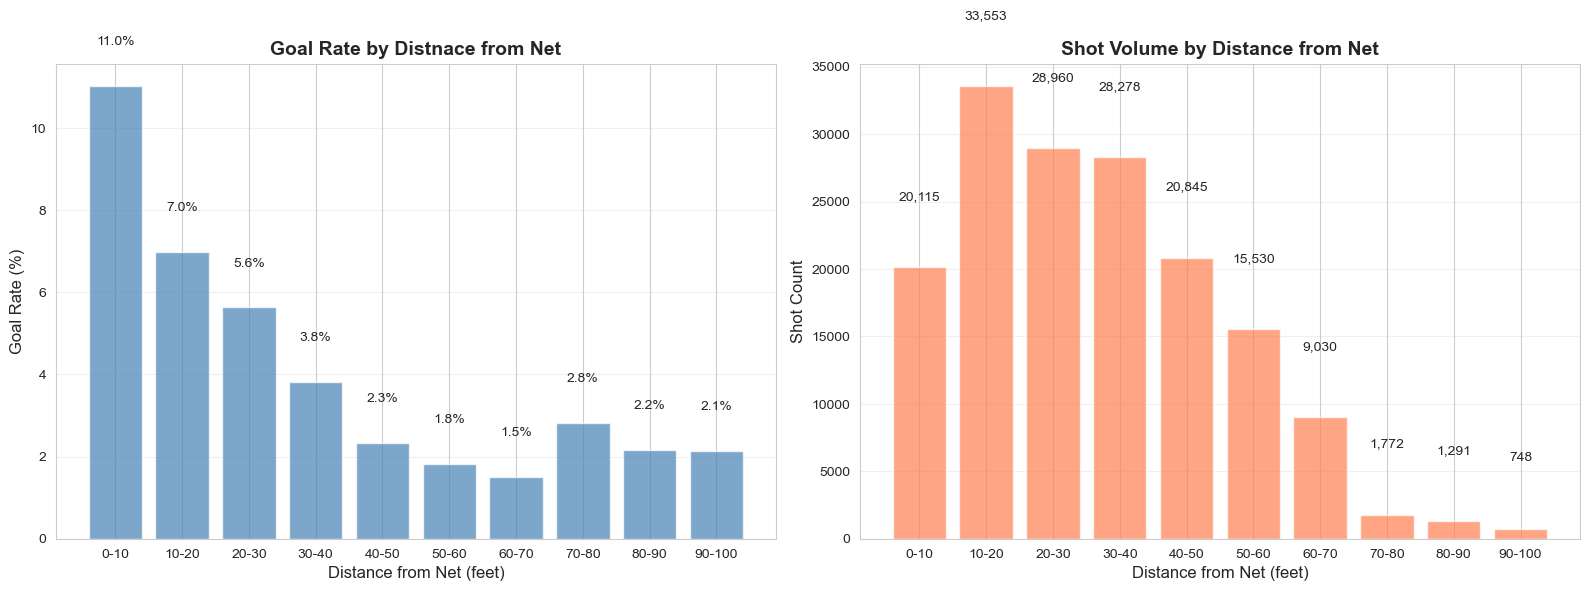


Goal Rate by Distance:
  distance_bin  goal_rate  shot_count
0         0-10   0.110167       20115
1        10-20   0.069860       33553
2        20-30   0.056285       28960
3        30-40   0.038122       28278
4        40-50   0.023315       20845
5        50-60   0.018287       15530
6        60-70   0.014950        9030
7        70-80   0.028217        1772
8        80-90   0.021689        1291
9       90-100   0.021390         748


In [108]:
## Goal Rate by Distance
# Create distance bins
df_shots_clean['distance_bin'] = pd.cut(df_shots_clean['distance'],
                    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])

# Calculate goal rate by distance bin
distance_goal_rate = df_shots_clean.groupby('distance_bin')['is_goal'].agg(['mean', 'count'])
distance_goal_rate.columns = ['goal_rate', 'shot_count']
distance_goal_rate = distance_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by distance
ax1.bar(distance_goal_rate['distance_bin'].astype(str),
       distance_goal_rate['goal_rate'] * 100,
       color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Distnace from Net', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(distance_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha = 'center', fontsize = 10)

# Shot count by distance
ax2.bar(distance_goal_rate['distance_bin'].astype(str),
        distance_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax2.set_ylabel('Shot Count', fontsize = 12)
ax2.set_title('Shot Volume by Distance from Net', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(distance_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Distance:")
print(distance_goal_rate)

### Goal Rate by Angle

C:\Users\prest\AppData\Local\Temp\ipykernel_22316\4221180471.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  angle_goal_rate = df_shots_clean.groupby('angle_bin')['is_goal'].agg(['mean', 'count'])


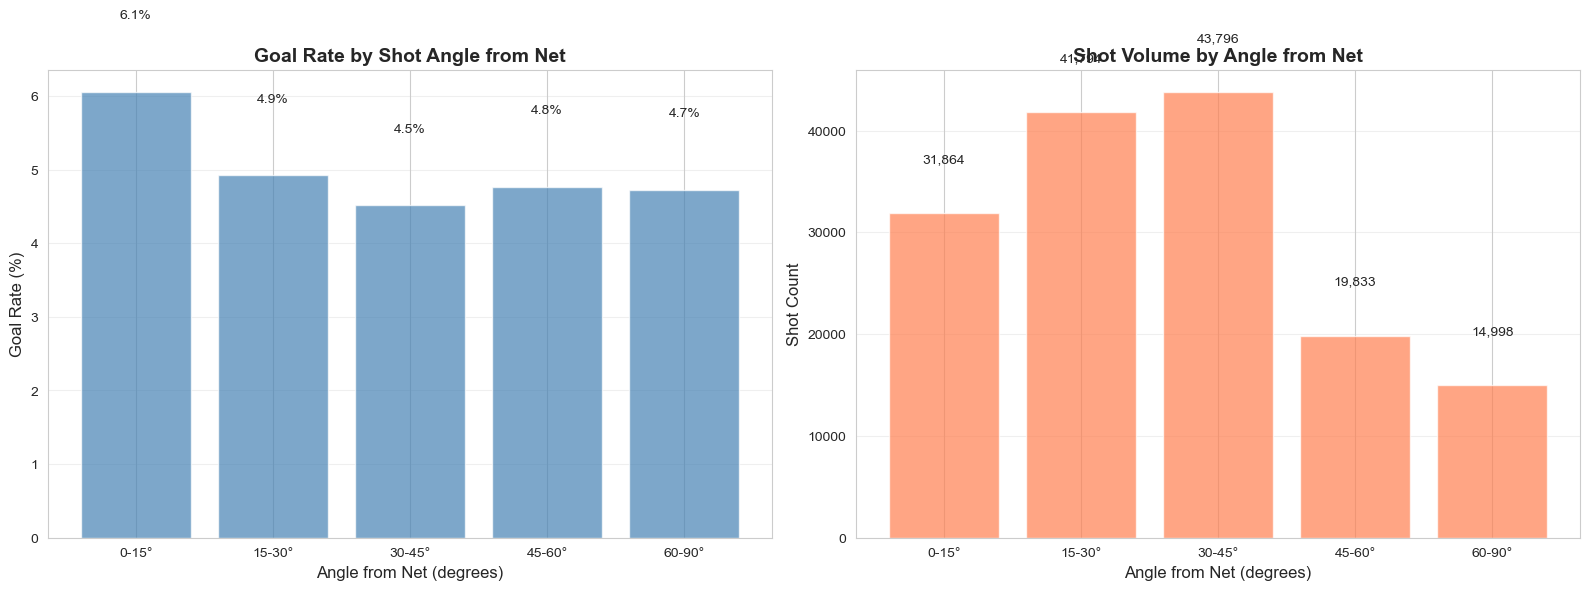


Goal Rate by Anlge:
  angle_bin  goal_rate  shot_count
0     0-15°   0.060570       31864
1    15-30°   0.049218       41794
2    30-45°   0.045141       43796
3    45-60°   0.047698       19833
4    60-90°   0.047206       14998


In [109]:
### Goal Rate by Angle
# Create angle bins(absolute value since angles can be negative)
df_shots_clean['angle_abs'] = df_shots_clean['angle'].abs()
df_shots_clean['angle_bin'] = pd.cut(df_shots_clean['angle_abs'],
                                     bins=[0, 15, 30, 45, 60, 90],
                                     labels=['0-15°', '15-30°', '30-45°', '45-60°','60-90°'])

# Calculate goal rate by angle bin
angle_goal_rate = df_shots_clean.groupby('angle_bin')['is_goal'].agg(['mean', 'count'])
angle_goal_rate.columns = ['goal_rate', 'shot_count']
angle_goal_rate = angle_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by angle
ax1.bar(angle_goal_rate['angle_bin'].astype(str),
        angle_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Angle from Net (degrees)', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Shot Angle from Net', fontsize = 14, fontweight = 'bold')
ax1.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(angle_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
              ha='center', fontsize = 10)

# Shot count by angle
ax2.bar(angle_goal_rate['angle_bin'].astype(str),
        angle_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Angle from Net (degrees)', fontsize = 12)
ax2.set_ylabel('Shot Count', fontsize = 12)
ax2.set_title('Shot Volume by Angle from Net', fontsize = 14, fontweight = 'bold')
ax2.grid(axis='y', alpha = 0.3)
for i, (idx, row) in enumerate(angle_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()
print("\nGoal Rate by Anlge:")
print(angle_goal_rate)

### Goal Rate by Shot Type

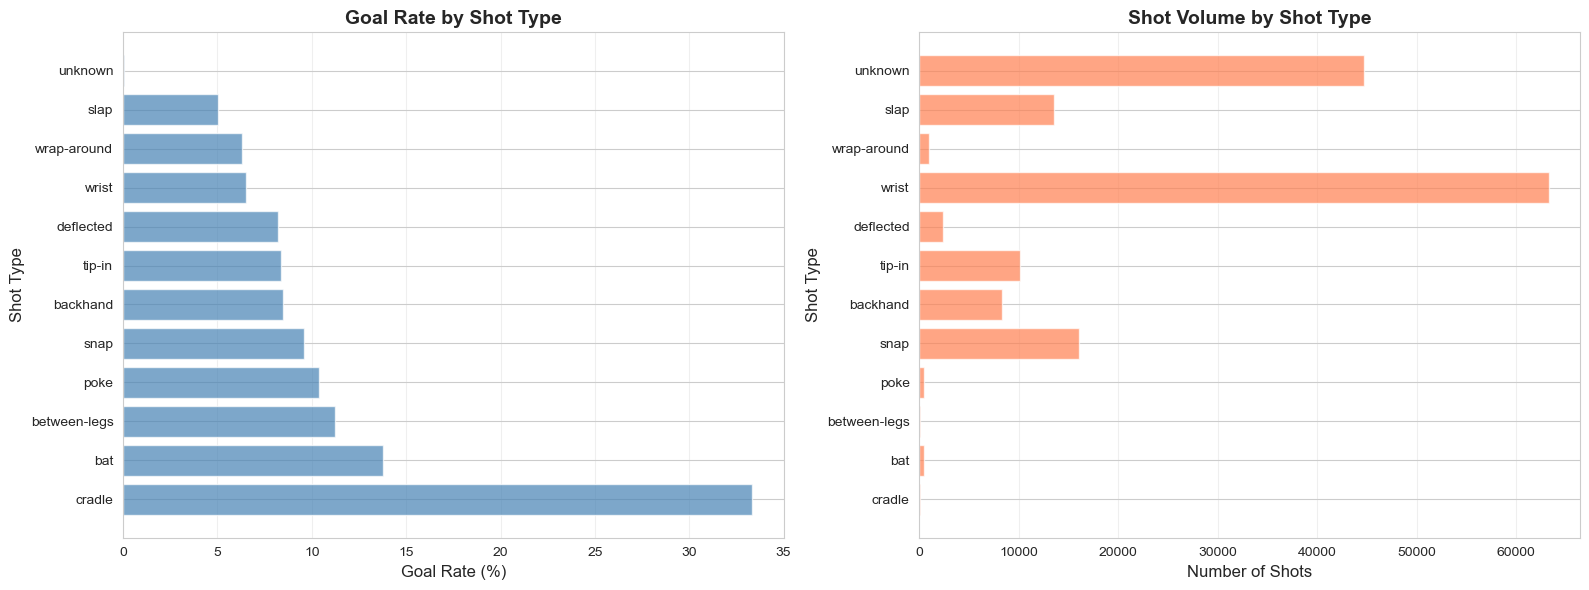


Goal Rate by Shot Type:
        shotType  goal_rate  shot_count
0         cradle   0.333333           9
1            bat   0.137529         429
2   between-legs   0.112500          80
3           poke   0.103687         434
4           snap   0.095754       16062
5       backhand   0.084862        8284
6         tip-in   0.083746       10102
7      deflected   0.082080        2327
8          wrist   0.065224       63244
9    wrap-around   0.062845         907
10          slap   0.050022       13554
11       unknown   0.000313       44691


In [110]:
### Goal Rate by Shot Type
shot_type_goal_rate = df_shots_clean.groupby('shotType')['is_goal'].agg(['mean', 'count'])
shot_type_goal_rate.columns = ['goal_rate', 'shot_count']
shot_type_goal_rate = shot_type_goal_rate.sort_values(by='goal_rate', ascending=False).reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Goal rate by shot type
ax1.barh(shot_type_goal_rate['shotType'],
         shot_type_goal_rate['goal_rate'] * 100,
         color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Goal Rate (%)', fontsize = 12)
ax1.set_ylabel('Shot Type', fontsize = 12)
ax1.set_title('Goal Rate by Shot Type', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'x', alpha = 0.3)

# Shot count by shot type
ax2.barh(shot_type_goal_rate['shotType'],
         shot_type_goal_rate['shot_count'],
         color = 'coral', alpha = 0.7)
ax2.set_xlabel('Number of Shots', fontsize = 12)
ax2.set_ylabel('Shot Type', fontsize = 12)
ax2.set_title('Shot Volume by Shot Type', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'x', alpha = 0.3)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Shot Type:")
print(shot_type_goal_rate)

### Goal Rate by Zone

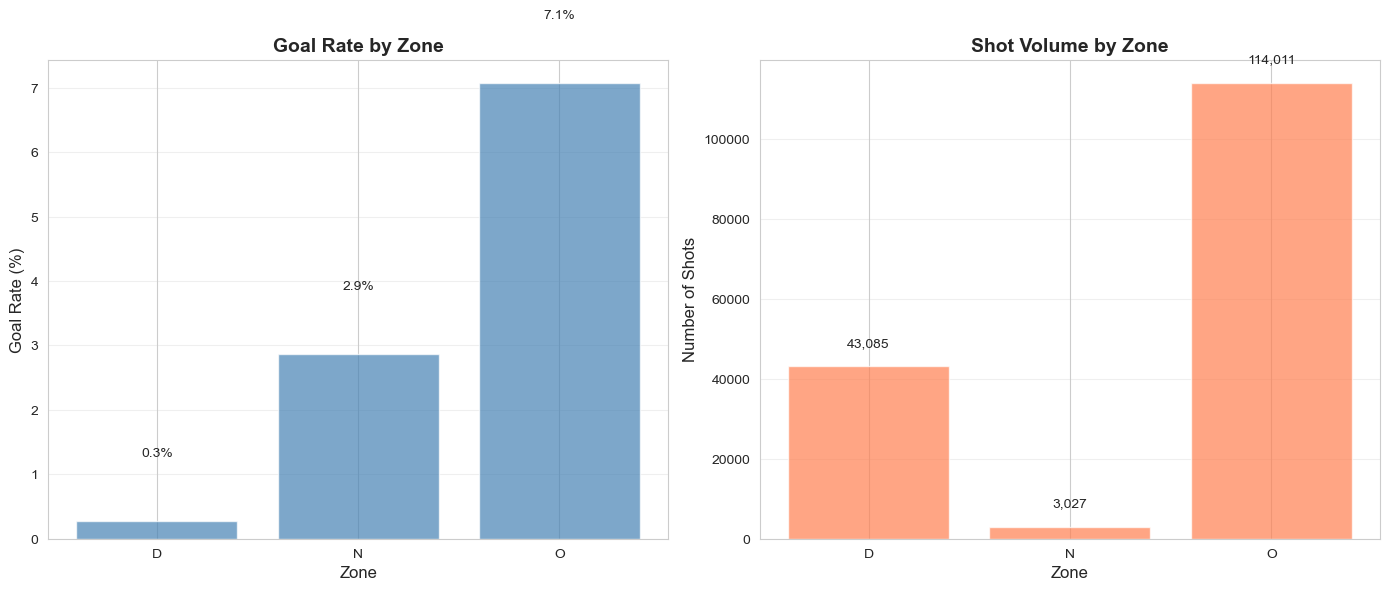


Goal Rate by Zone:
  zoneCode  goal_rate  shot_count
0        D   0.002692       43085
1        N   0.028741        3027
2        O   0.070739      114011


In [111]:
### Goal Rate by Zone
zone_goal_rate = df_shots_clean.groupby('zoneCode')['is_goal'].agg(['mean', 'count'])
zone_goal_rate.columns = ['goal_rate', 'shot_count']
zone_goal_rate = zone_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Goal rate by zone
ax1.bar(zone_goal_rate['zoneCode'],
        zone_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Zone', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Zone', fontsize =14, fontweight = 'bold')
ax1.grid(axis='y', alpha = 0.3)
for i, (idx, row) in enumerate(zone_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha='center', fontsize = 10)

# Shot count by zone
ax2.bar(zone_goal_rate['zoneCode'],
        zone_goal_rate['shot_count'],
        color='coral', alpha = 0.7)
ax2.set_xlabel('Zone', fontsize = 12)
ax2.set_ylabel('Number of Shots', fontsize = 12)
ax2.set_title('Shot Volume by Zone', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(zone_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Zone:")
print(zone_goal_rate)

### Goal Rate by Period

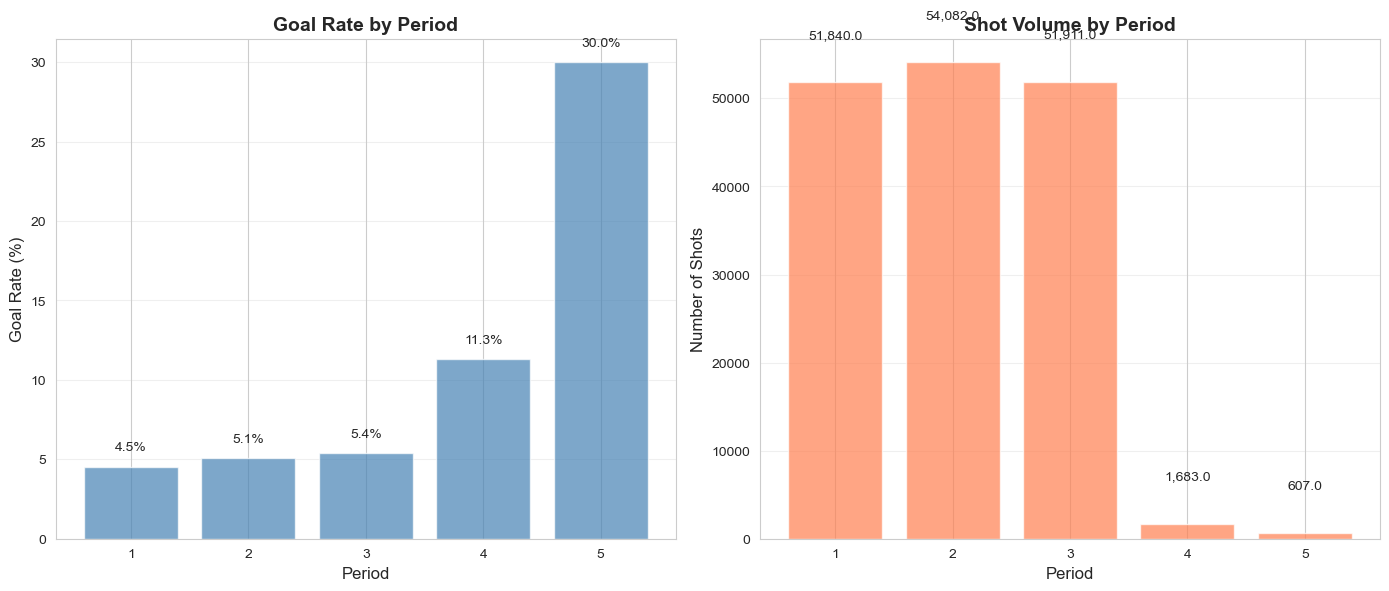


Goal Rate by Period:
   period  goal_rate  shot_count
0       1   0.045312       51840
1       2   0.050886       54082
2       3   0.053842       51911
3       4   0.112894        1683
4       5   0.299835         607


In [112]:
### Goal Rate by period
period_goal_rate = df_shots_clean.groupby('period')['is_goal'].agg(['mean', 'count'])
period_goal_rate.columns = ['goal_rate', 'shot_count']
period_goal_rate = period_goal_rate.reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))

# Goal rate by period
ax1.bar(period_goal_rate['period'].astype(str),
        period_goal_rate['goal_rate'] * 100,
        color = 'steelblue', alpha = 0.7)
ax1.set_xlabel('Period', fontsize = 12)
ax1.set_ylabel('Goal Rate (%)', fontsize = 12)
ax1.set_title('Goal Rate by Period', fontsize = 14, fontweight = 'bold')
ax1.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(period_goal_rate.iterrows()):
    ax1.text(i, row['goal_rate'] * 100 + 1, f"{row['goal_rate']:.1%}",
             ha = 'center', fontsize = 10)

# Shot count by period
ax2.bar(period_goal_rate['period'].astype(str),
        period_goal_rate['shot_count'],
        color = 'coral', alpha = 0.7)
ax2.set_xlabel('Period', fontsize = 12)
ax2.set_ylabel('Number of Shots', fontsize = 12)
ax2.set_title('Shot Volume by Period', fontsize = 14, fontweight = 'bold')
ax2.grid(axis = 'y', alpha = 0.3)
for i, (idx, row) in enumerate(period_goal_rate.iterrows()):
    ax2.text(i, row['shot_count'] + 5000, f"{row['shot_count']:,}",
             ha = 'center', fontsize = 10)

plt.tight_layout()
plt.show()

print("\nGoal Rate by Period:")
print(period_goal_rate)


### Shot Location Heat Map

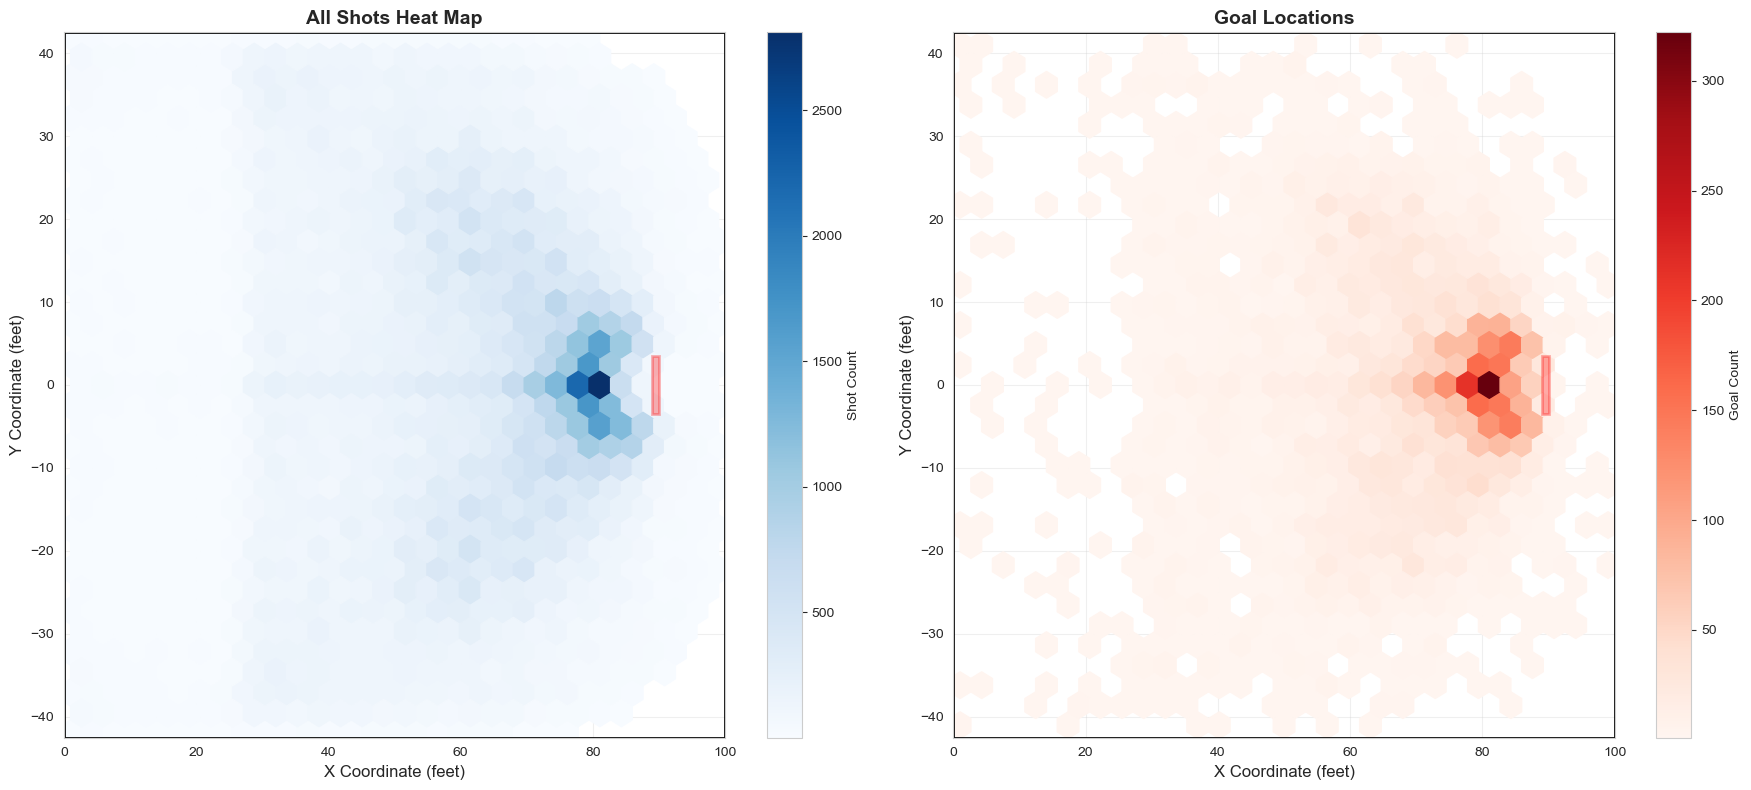

In [113]:
### Shot Location Heat Map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (18, 8))

# Filter to offensive zone shots (xCoord > 0)
offensive_shots = df_shots_clean[df_shots_clean['xCoord'] > 0].copy()

# All shots heatmap
h1 = ax1.hexbin(offensive_shots['xCoord'], offensive_shots['yCoord'],
                gridsize = 30, cmap = 'Blues', mincnt = 1)
ax1.set_xlabel('X Coordinate (feet)', fontsize = 12)
ax1.set_ylabel('Y Coordinate (feet)', fontsize = 12)
ax1.set_title('All Shots Heat Map', fontsize = 14, fontweight = 'bold')
ax1.set_xlim(0, 100)
ax1.set_ylim(-42.5, 42.5)
ax1.grid(True, alpha = 0.3)
plt.colorbar(h1, ax = ax1, label = 'Shot Count')

# Draw rink outline
rink_rect = Rectangle((0, -42.5), 100, 85, linewidth = 2, edgecolor = 'black', fill = False)
ax1.add_patch(rink_rect)
goal_line = Rectangle((89, -3.5), 1, 7, linewidth = 2, edgecolor = 'red', fill = True, facecolor = 'red', alpha = 0.3)
ax1.add_patch(goal_line)

# Goals heatmap
goals = offensive_shots[offensive_shots['is_goal'] == 1]
h2 = ax2.hexbin(goals['xCoord'], goals['yCoord'],
                gridsize = 30, cmap = 'Reds', mincnt = 1)
ax2.set_xlabel('X Coordinate (feet)', fontsize = 12)
ax2.set_ylabel('Y Coordinate (feet)', fontsize = 12)
ax2.set_title('Goal Locations', fontsize = 14, fontweight = 'bold')
ax2.set_xlim(0, 100)
ax2.set_ylim(-42.5, 42.5)
ax2.grid(True, alpha = 0.3)
plt.colorbar(h2, ax = ax2, label = 'Goal Count')

# Draw rink outline
rink_rect2 = Rectangle((0, -42.5), 100, 85, linewidth = 2, edgecolor = 'black', fill = False)
ax2.add_patch(rink_rect2)
goal_line2 = Rectangle((89, -3.5), 1, 7, linewidth = 2, edgecolor = 'red', fill = True, facecolor = 'red', alpha = 0.3)
ax2.add_patch(goal_line2)

plt.tight_layout()
plt.show()

### Distance vs Angle Scatter Plot

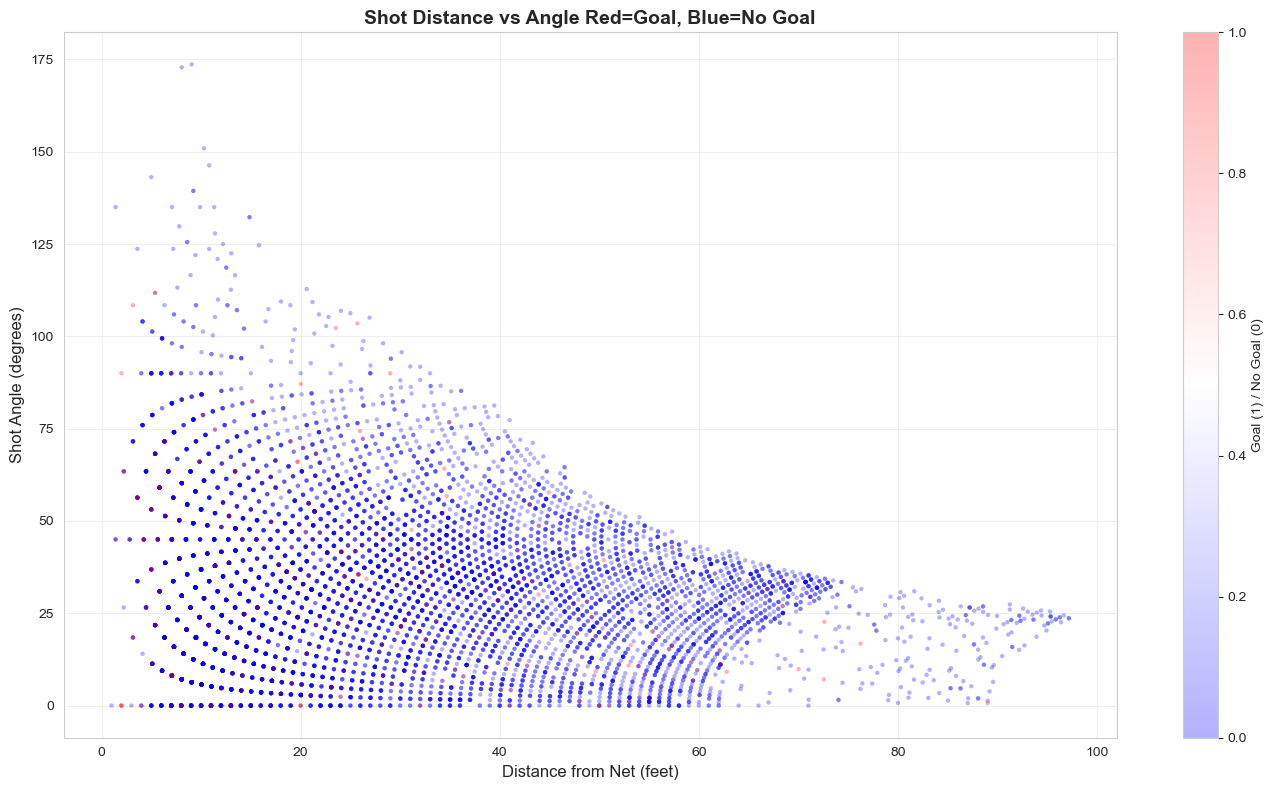

In [114]:
### Distance vs Angle Analysis
fig, ax = plt.subplots(figsize = (14, 8))

# Sample data for performace (optional - remove if you want all data points)
sample_size = 10000
if len(df_shots_clean) > sample_size:
    sample_df = df_shots_clean.sample(n = sample_size, random_state = 42)
else:
    sample_df = df_shots_clean

# Scatter plot colored by goal
scatter = ax.scatter(sample_df['distance'], sample_df['angle'].abs(),
                     c = sample_df['is_goal'], cmap = 'bwr',
                     alpha = 0.3, s = 10, edgecolors = 'none')

ax.set_xlabel('Distance from Net (feet)', fontsize = 12)
ax.set_ylabel('Shot Angle (degrees)', fontsize = 12)
ax.set_title('Shot Distance vs Angle Red=Goal, Blue=No Goal', fontsize = 14, fontweight = 'bold')
ax.grid(True, alpha = 0.3)
plt.colorbar(scatter, ax = ax, label = 'Goal (1) / No Goal (0)')

plt.tight_layout()
plt.show()

### Correlation Analysis

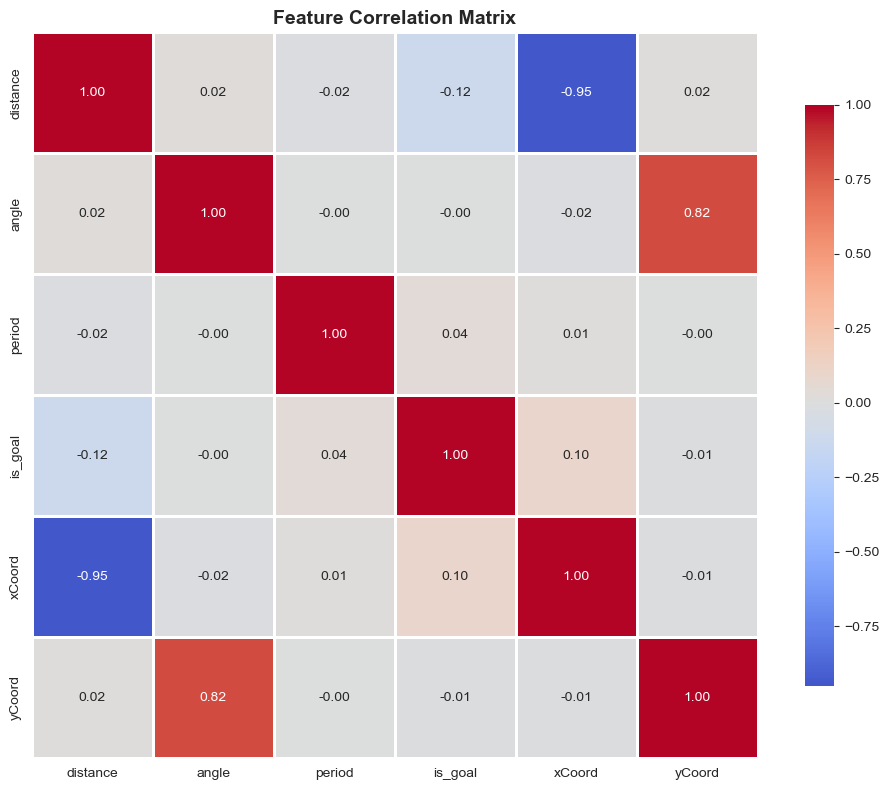


Correlation with Goal:
is_goal     1.000000
xCoord      0.097404
period      0.036526
angle      -0.003341
yCoord     -0.005440
distance   -0.119958
Name: is_goal, dtype: float64


In [115]:
### Correlation Analysis
# Select numeric columns for correlation
numeric_cols = ['distance', 'angle', 'period', 'is_goal', 'xCoord', 'yCoord']
corr_data = df_shots_clean[numeric_cols].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Goal:")
print(corr_data['is_goal'].sort_values(ascending=False))

## Additional Feature Engineering

In [116]:
### Game Situation Features - Simplified Approach
print("Creating game situation features...")

def extract_situation_simple(situation_code):
    """Simplified extraction - treat common codes as even strength"""
    if pd.isna(situation_code):
        return 'even_strength'
    
    code_str = str(int(situation_code))
    
    # Most common code "1551" is likely even strength (5v5)
    # Check for empty net first (has 0 in first two digits)
    if code_str[0] == '0' or code_str[1] == '0':
        return 'empty_net'
    
    # Common even strength codes (based on your data)
    even_strength_codes = ['1551', '1451', '1541', '1441', '1331', '1351', '1560']
    if code_str in even_strength_codes:
        return 'even_strength'
    
    # Everything else is man-advantage (we'll classify PP/PK separately)
    return 'man_advantage'

# Apply simple classification
df_shots_clean['game_situation'] = df_shots_clean['situationCode'].apply(extract_situation_simple)

# For man_advantage situations, determine PP vs PK
# We'd need eventOwnerTeamId and home/away team IDs to do this accurately
# For now, let's keep them as a separate category or use a heuristic

print("\nGame Situation Distribution:")
print(df_shots_clean['game_situation'].value_counts())
print("\nGoal Rate by Game Situation:")
print(df_shots_clean.groupby('game_situation')['is_goal'].agg(['mean', 'count']))

# Create binary features
df_shots_clean['is_even_strength'] = (df_shots_clean['game_situation'] == 'even_strength').astype(int)
df_shots_clean['is_empty_net'] = (df_shots_clean['game_situation'] == 'empty_net').astype(int)
df_shots_clean['is_man_advantage'] = (df_shots_clean['game_situation'] == 'man_advantage').astype(int)

Creating game situation features...

Game Situation Distribution:
game_situation
even_strength    155964
man_advantage      3506
empty_net           653
Name: count, dtype: int64

Goal Rate by Game Situation:
                    mean   count
game_situation                  
empty_net       0.303216     653
even_strength   0.048973  155964
man_advantage   0.123217    3506


### Time-based Features

In [117]:
### Time-based Features
print("\nCreating time-based features...")

# Convert tie strings to seconds for easier calculations
def time_to_seconds(time_str):
    if pd.isna(time_str):
        return None
    try:
        parts = str(time_str).split(':')
        if len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
        return None
    except:
        None

# Create time features
df_shots_clean['time_in_period_seconds'] = df_shots_clean['timeInPeriod'].apply(time_to_seconds)
df_shots_clean['time_remaining_seconds'] = df_shots_clean['timeRemaining'].apply(time_to_seconds)

# Time remaining in game (approximate - 20 min periods)
df_shots_clean['time_remaining_game'] = (
    (df_shots_clean['period'] - 1) * 1200 + df_shots_clean['time_remaining_seconds']
)

# Period type features
df_shots_clean['is_regulation'] = (df_shots_clean['periodType'] == 'REG').astype(int)
df_shots_clean['is_overtime'] = (df_shots_clean['periodType'] == 'OT').astype(int)
df_shots_clean['is_shootout'] = (df_shots_clean['periodType'] == 'SO').astype(int)

# Late game indicator (last 5 mins of regulation)
df_shots_clean['is_late_game'] = (
    (df_shots_clean['period'] <= 3) &
    (df_shots_clean['time_remaining_seconds'] <= 300)
).astype(int)

# Early period indicator (first 2 mins)
df_shots_clean['is_early_period'] = (
    df_shots_clean['time_remaining_seconds'] >= 1080
).astype(int)

print("Time-based features created!")
print("\nGoal Rate by Period Type:")
print(df_shots_clean.groupby('periodType')['is_goal'].agg(['mean', 'count']))
print("\nGoal Rate - Late Game (last 5 min):")
print(df_shots_clean.groupby('is_late_game')['is_goal'].agg(['mean', 'count']))  # FIXED: Removed incorrect indexing
print("\nGoal Rate - Early Period (first 2 mins):")
print(df_shots_clean.groupby('is_early_period')['is_goal'].agg(['mean', 'count']))  # FIXED: Removed incorrect indexing


Creating time-based features...
Time-based features created!

Goal Rate by Period Type:
                mean   count
periodType                  
OT          0.112894    1683
REG         0.050028  157833
SO          0.299835     607

Goal Rate - Late Game (last 5 min):
                  mean   count
is_late_game                  
0             0.049758  119860
1             0.057224   40263

Goal Rate - Early Period (first 2 mins):
                     mean   count
is_early_period                  
0                0.052231  145087
1                0.045890   15036


### Shot Quality Metrics

In [118]:
### Shot Quality Metrics
print("\nCreating Shot Quality Metrics...")

# Distance-angle interaction (closer shots with better angles are higher quality)
df_shots_clean['distance_angle_interaction'] = (
    df_shots_clean['distance'] * df_shots_clean['angle'].abs()
)

# Shot quality score (inverse relationship - lower is better)
# Normalize distance (0-100 feet) and angle (0-90 degrees)
df_shots_clean['normalized_distance'] = df_shots_clean['distance'] / 100
df_shots_clean['normalized_angle'] = df_shots_clean['angle'].abs() / 90

# Combined quality metric (lower = better shot)
df_shots_clean['shot_quality_score'] = (
    df_shots_clean['normalized_distance'] * 0.6 +
    df_shots_clean['normalized_angle'] * 0.4
)

# High danger area (slot area = close and centered)
# Typically distance < 25 feet and angle < 30 degrees
df_shots_clean['is_high_danger'] = (
    (df_shots_clean['distance'] < 25) &
    (df_shots_clean['angle'].abs()< 30)
).astype(int)

# Medium danger area
df_shots_clean['is_medium_danger'] = (
    (df_shots_clean['distance'] < 40) &
    (df_shots_clean['angle'].abs() < 45) &
    ~df_shots_clean['is_high_danger']
).astype(int)

# Low danger area (everything else)
df_shots_clean['is_low_danger'] = (
    ~df_shots_clean['is_high_danger'] &
    ~df_shots_clean['is_medium_danger']
).astype(int)

print("Shot quality metrics created!")
print("\nGoal Rate by Danger Zone:")
danger_zones = []
for zone in ['is_high_danger', 'is_medium_danger', 'is_low_danger']:
    goal_rate = df_shots_clean[df_shots_clean[zone] == 1]['is_goal'].mean()
    count = df_shots_clean[df_shots_clean[zone] == 1][zone].sum()
    danger_zones.append({
        'zone': zone.replace('is_', '').replace('_', ' ').title(),
        'goal_rate': goal_rate,
        'shot_count': count
    })
print(pd.DataFrame(danger_zones))


Creating Shot Quality Metrics...
Shot quality metrics created!

Goal Rate by Danger Zone:
            zone  goal_rate  shot_count
0    High Danger   0.086736       33308
1  Medium Danger   0.056447       42394
2     Low Danger        NaN           0


### Rebound Features

In [119]:
### Rebound Features
print("\nCreating rebound features...")

# Sort by eventId to maintain chronological order within games
# Note: You may need to sort by Game ID and eventId if you have game identifiers
df_shots_clean_sorted = df_shots_clean.sort_values('eventId').reset_index(drop=True)

# Check if previous shot was within X seconds (using eventId as proxy)
# for a more accurate rebound, you'd need actual timestamps
# This is a simplified version using eventId proximity

# Create a shifted version to compare with previous shot
df_shots_clean_sorted['prev_event_id'] = df_shots_clean_sorted['eventId'].shift(1)
df_shots_clean_sorted['event_id_diff'] = (
    df_shots_clean_sorted['eventId'] - df_shots_clean_sorted['prev_event_id']
)

# Consider it a potential rebound if events are close together
# (within 3? event IDs - guessing)
df_shots_clean_sorted['is_potential_rebound'] = (
    (df_shots_clean_sorted['event_id_diff'] <= 5) &
    (df_shots_clean_sorted['event_id_diff'] > 0)
).astype(int)

# Update original dataframe
df_shots_clean['is_potential_rebound'] = df_shots_clean_sorted['is_potential_rebound'].values

print("Rebound features created!")
print("\nGoal Rate = Potential Rebounds:")
print(df_shots_clean.groupby('is_potential_rebound')['is_goal'].agg(['mean', 'count']))


Creating rebound features...
Rebound features created!

Goal Rate = Potential Rebounds:
                          mean   count
is_potential_rebound                  
0                     0.051577  158520
1                     0.057392    1603


### Shot Type Features

In [120]:
### Shot Type Features
print("\nCreating shot type features...")

# One-hot encode shot types (keep most common ones, group others)
common_shot_types = ['wrist', 'snap', 'slap', 'tip-in', 'backhand', 'deflected']
df_shots_clean['shot_type_grouped'] = df_shots_clean['shotType'].apply(
    lambda x: x if x in common_shot_types else 'other'
)

# Create binary features for common shot types
for shot_type in common_shot_types:
    df_shots_clean[f'is_{shot_type}'] = (
        df_shots_clean['shotType'] == shot_type
    ).astype(int)

print("Shot type features created!")
print("\nGoal Rate by Shot Type (Top 6):")
top_shot_types = df_shots_clean.groupby('shotType')['is_goal'].agg(['mean', 'count'])
top_shot_types = top_shot_types.sort_values('count', ascending=False).head(6)
print(top_shot_types)


Creating shot type features...
Shot type features created!

Goal Rate by Shot Type (Top 6):
              mean  count
shotType                 
wrist     0.065224  63244
unknown   0.000313  44691
snap      0.095754  16062
slap      0.050022  13554
tip-in    0.083746  10102
backhand  0.084862   8284


### Zone Features

In [121]:
### Zone Features
print("\nCreating zone features...")

# One-hot encode zones
df_shots_clean['is_offensive_zone'] = (df_shots_clean['zoneCode'] == 'O').astype(int)
df_shots_clean['is_defensive_zone'] = (df_shots_clean['zoneCode'] == 'D').astype(int)
df_shots_clean['is_neutral_zone'] = (df_shots_clean['zoneCode'] == 'N').astype(int)

print("Zone features created!")
print("\nGoal Rate by Zone:")
print(df_shots_clean.groupby('zoneCode')['is_goal'].agg(['mean', 'count']))


Creating zone features...
Zone features created!

Goal Rate by Zone:
              mean   count
zoneCode                  
D         0.002692   43085
N         0.028741    3027
O         0.070739  114011


### New Feature Summary

In [122]:
### Summary of New Features
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)

print(f"\nTotal features created: {len([col for col in df_shots_clean.columns if col not in ['eventId', 'timeInPeriod', 'timeRemaining', 'situationCode', 'typeDescKey', 'typeCode', 'sortOrder', 'assist1PlayerId', 'assist1PlayerTotal', 'assist2PlayerId', 'assist2PlayerTotal', 'awaySOG', 'awayScore', 'blockingPlayerId', 'eventOwnerTeamId', 'goalieInNetId', 'homeSOG', 'homeScore', 'scoringPlayerId', 'scoringPlayerTotal', 'shootingPlayerId', 'xCoord', 'yCoord', 'zoneCode', 'period', 'periodType', 'shotType']])}")

print("\nNew Features Created:")
new_features = [
    'distance', 'angle', 'is_goal',  # Original engineered
    'home_strength', 'away_strength', 'game_situation',
    'is_power_play', 'is_penalty_kill', 'is_even_strength', 'is_empty_net',
    'time_in_period_seconds', 'time_remaining_seconds', 'time_remaining_game',
    'is_regulation', 'is_overtime', 'is_shootout',
    'is_late_game', 'is_early_period',
    'distance_angle_interaction', 'normalized_distance', 'normalized_angle',
    'shot_quality_score', 'is_high_danger', 'is_medium_danger', 'is_low_danger',
    'is_potential_rebound',
    'shot_type_grouped', 'is_wrist', 'is_snap', 'is_slap', 'is_tip-in', 'is_backhand', 'is_deflected',
    'is_offensive_zone', 'is_neutral_zone', 'is_defensive_zone'
]

for feature in new_features:
    if feature in df_shots_clean.columns:
        print(f"  ✓ {feature}")

print(f"\nDataFrame shape: {df_shots_clean.shape}")
print(f"\nSample of new features:")
display_cols = ['distance', 'angle', 'game_situation', 'is_high_danger', 
                'is_power_play', 'time_remaining_game', 'shot_quality_score']

# FIXED: Only include columns that actually exist in the dataframe
display_cols = [col for col in display_cols if col in df_shots_clean.columns]

print(df_shots_clean[display_cols].head(10))


FEATURE ENGINEERING SUMMARY

Total features created: 37

New Features Created:
  ✓ distance
  ✓ angle
  ✓ is_goal
  ✓ game_situation
  ✓ is_even_strength
  ✓ is_empty_net
  ✓ time_in_period_seconds
  ✓ time_remaining_seconds
  ✓ time_remaining_game
  ✓ is_regulation
  ✓ is_overtime
  ✓ is_shootout
  ✓ is_late_game
  ✓ is_early_period
  ✓ distance_angle_interaction
  ✓ normalized_distance
  ✓ normalized_angle
  ✓ shot_quality_score
  ✓ is_high_danger
  ✓ is_medium_danger
  ✓ is_low_danger
  ✓ is_potential_rebound
  ✓ shot_type_grouped
  ✓ is_wrist
  ✓ is_snap
  ✓ is_slap
  ✓ is_tip-in
  ✓ is_backhand
  ✓ is_deflected
  ✓ is_offensive_zone
  ✓ is_neutral_zone
  ✓ is_defensive_zone

DataFrame shape: (160123, 65)

Sample of new features:
    distance      angle game_situation  is_high_danger  time_remaining_game  \
0  39.824616 -38.884496  even_strength               0                 1139   
1  11.313708  45.000000  even_strength               0                 1130   
2  45.343136  41.4

## Model Building

### Step 1: Data Preparation

In [123]:
## Model Building - Data Preparation

print("="*60)
print("STEP 1: DATA PREPARATION")
print(""*60)

# Check for missing values
print("\nChecking for missing values:")
missing_data = df_shots_clean.isnull().sum()
missing_data = missing_data[missing_data > 0]
if len(missing_data) > 0:
    print(missing_data)
else:
    print("No missing values found!")

# Check data types
print("\nData types:")
print(df_shots_clean.dtypes.value_counts())

# Select features for modeling
# Exclude non-numeric and identifier columns
exclude_cols = [
    'eventId', 'timeInPeriod', 'timeRemaining', 'situationCode', 
    'typeDescKey', 'typeCode', 'sortOrder', 'assist1PlayerId', 
    'assist1PlayerTotal', 'assist2PlayerId', 'assist2PlayerTotal',
    'awaySOG', 'awayScore', 'blockingPlayerId', 'eventOwnerTeamId', 
    'goalieInNetId', 'homeSOG', 'homeScore', 'scoringPlayerId', 
    'scoringPlayerTotal', 'shootingPlayerId', 'xCoord', 'yCoord', 
    'zoneCode', 'period', 'periodType', 'shotType', 'homeTeamDefendingSide',
    'home_strength', 'away_strength', 'game_situation', 'shot_type_grouped'  # Categorical columns we've encoded
]

# Get all feature columns (everything expect target and excluded columns)
feature_cols = [col for col in df_shots_clean.columns
                if col not in exclude_cols and col != 'is_goal']

print(f"\nNumber of features: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Create feature Matrix X and targeted vector y
X = df_shots_clean[feature_cols].copy()
y = df_shots_clean['is_goal'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nGoal rate: {y.mean():.2%}")
print(f"Total shots: {len(y):,}")
print(f"Total goals: {y.sum():,}")

STEP 1: DATA PREPARATION


Checking for missing values:
awaySOG                88408
awayScore             151855
blockingPlayerId      115454
goalieInNetId          45457
homeSOG                88408
homeScore             151855
scoringPlayerId       151855
scoringPlayerTotal    152037
shootingPlayerId        8268
typeCode              160123
distance_bin               1
angle_bin               7838
dtype: int64

Data types:
int32       22
float64     19
object      15
int64        7
category     1
category     1
Name: count, dtype: int64

Number of features: 33

Feature columns:
  1. distance
  2. angle
  3. distance_bin
  4. angle_abs
  5. angle_bin
  6. is_even_strength
  7. is_empty_net
  8. is_man_advantage
  9. time_in_period_seconds
  10. time_remaining_seconds
  11. time_remaining_game
  12. is_regulation
  13. is_overtime
  14. is_shootout
  15. is_late_game
  16. is_early_period
  17. distance_angle_interaction
  18. normalized_distance
  19. normalized_angle
  20. shot_qual

In [124]:
## Identify and Handle Categorical Features

print("="*60)
print("IDENTIFYING CATEGORICAL FEATURES")
print("="*60)

# Check for non-numeric columns
non_numeric_cols = []
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        non_numeric_cols.append(col)
        print(f"  Found categorical: {col}")
        print(f"    Sample values: {X[col].unique()[:5]}")
        print(f"    Data type: {X[col].dtype}")

if len(non_numeric_cols) == 0:
    print("\n✓ No categorical features found - all features are numeric!")
else:
    print(f"\n⚠ Found {len(non_numeric_cols)} categorical feature(s) that need encoding")

IDENTIFYING CATEGORICAL FEATURES
  Found categorical: distance_bin
    Sample values: ['30-40', '10-20', '40-50', '20-30', '60-70']
Categories (10, object): ['0-10' < '10-20' < '20-30' < '30-40' ... '60-70' < '70-80' < '80-90' < '90-100']
    Data type: category
  Found categorical: angle_bin
    Sample values: ['30-45°', '45-60°', '60-90°', '15-30°', '0-15°']
Categories (5, object): ['0-15°' < '15-30°' < '30-45°' < '45-60°' < '60-90°']
    Data type: category

⚠ Found 2 categorical feature(s) that need encoding


In [125]:
## Alternative: Encode Categorical Features (if you want to keep them)

from sklearn.preprocessing import LabelEncoder

print("="*60)
print("ENCODING CATEGORICAL FEATURES")
print("="*60)

# Find categorical columns
categorical_cols = [col for col in X.columns 
                    if X[col].dtype == 'object' or X[col].dtype.name == 'category']

if len(categorical_cols) > 0:
    print(f"\nEncoding {len(categorical_cols)} categorical feature(s)...")
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
        print(f"  ✓ Encoded: {col} ({len(le.classes_)} unique values)")
    
    print("\n✓ All categorical features encoded!")
else:
    print("\n✓ No categorical features to encode")

ENCODING CATEGORICAL FEATURES

Encoding 2 categorical feature(s)...
  ✓ Encoded: distance_bin (11 unique values)
  ✓ Encoded: angle_bin (6 unique values)

✓ All categorical features encoded!


In [126]:
## Final Data Type Check

print("="*60)
print("FINAL DATA TYPE VERIFICATION")
print("="*60)

# Check all columns are numeric
print("\nData types:")
print(X.dtypes.value_counts())

# Check for any remaining issues
issues = []
for col in X.columns:
    # Check for non-numeric
    if not pd.api.types.is_numeric_dtype(X[col]):
        issues.append(f"{col}: non-numeric dtype ({X[col].dtype})")
    # Check for infinite values
    if pd.api.types.is_numeric_dtype(X[col]):
        if np.isinf(X[col]).any():
            issues.append(f"{col}: contains infinite values")
    # Check for object dtype with string values
    if X[col].dtype == 'object':
        try:
            X[col].astype(float)
        except:
            issues.append(f"{col}: cannot convert to float")

if len(issues) == 0:
    print("\n✓ All features are ready for modeling!")
    print(f"  Total features: {len(X.columns)}")
    print(f"  All numeric: ✓")
    print(f"  No infinite values: ✓")
    print(f"  No missing values: {X.isnull().sum().sum() == 0}")
else:
    print("\n⚠ Issues found:")
    for issue in issues:
        print(f"  - {issue}")
    print("\nPlease fix these issues before training the model")

FINAL DATA TYPE VERIFICATION

Data types:
int32      23
float64     7
int64       3
Name: count, dtype: int64

✓ All features are ready for modeling!
  Total features: 33
  All numeric: ✓
  No infinite values: ✓
  No missing values: True


### Step 2: Train/Test Split

In [127]:
## Train/Test Split
from sklearn.model_selection import train_test_split

print("="*60)
print("STEP 2: TRAIN/TEST SPLIT")
print("="*60)

# Split the data (80% train, 20% test)
#Using stratify = y to maintain goal rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set:")
print(f"  Size: {len(X_train):,} shots")
print(f"  Goals: {y_train.sum():,}")
print(f"  Goal rate: {y_train.mean():.2%}")

print(f"\nTest set:")
print(f"  Size: {len(X_test):,} shots")
print(f"  Goals: {y_test.sum():,}")
print(f"  Goal rate: {y_test.mean():.2%}")

# Verify the split maintainted the goal rate
assert abs(y_train.mean() - y_test.mean()) < 0.01, "Goal rates should be similar"
print("\nSplit successful - goal rates are similar in both sets")

STEP 2: TRAIN/TEST SPLIT

Training set:
  Size: 128,098 shots
  Goals: 6,614
  Goal rate: 5.16%

Test set:
  Size: 32,025 shots
  Goals: 1,654
  Goal rate: 5.16%

Split successful - goal rates are similar in both sets


### Step 3: Baseline Model - Logistic Regression

In [128]:
### Step 3: Baseline Model - Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("STEP 3: BASELINE MODEL - LOGISTIC REGRESSION")
print("="* 60)

# Create and train the model
print("\nTraining logistic regression model...")
lr_model = LogisticRegression(
    max_iter=1000, # Increase max iterations for convergence
    random_state=42,
    n_jobs= -1
)

lr_model.fit(X_train, y_train)
print("Model trained!")

# Make predictions
y_train_pred_proba = lr_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = lr_model.predict_proba(X_test)[:, 1]
y_test_pred = lr_model.predict(X_test)

# Calculate metrics
train_auc = roc_auc_score(y_train, y_train_pred_proba)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"\nModel Performance:")
print(f"  Training AUC: {train_auc:.4f}")
print(f"  Test Auc: {test_auc:.4f}")

# Classification report
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['No Goal', 'Goal']))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix (Test Set):")
print(f"                Predicted")
print(f"               No Goal Goal")
print(f"Actual No Goal   {cm[0,0]:6d}  {cm[0,1]:4d}")
print(f"      Goal       {cm[1,0]:6d}  {cm[1,1]:4d}")

STEP 3: BASELINE MODEL - LOGISTIC REGRESSION

Training logistic regression model...
Model trained!

Model Performance:
  Training AUC: 0.8045
  Test Auc: 0.8025

Classification Report (Test Set):
              precision    recall  f1-score   support

     No Goal       0.95      1.00      0.97     30371
        Goal       0.33      0.01      0.01      1654

    accuracy                           0.95     32025
   macro avg       0.64      0.50      0.49     32025
weighted avg       0.92      0.95      0.92     32025


Confusion Matrix (Test Set):
                Predicted
               No Goal Goal
Actual No Goal    30353    18
      Goal         1645     9


### Step 4: Model Evaluation - ROC Curve

STEP 4: MODEL EVALUATION - ROC CURVE


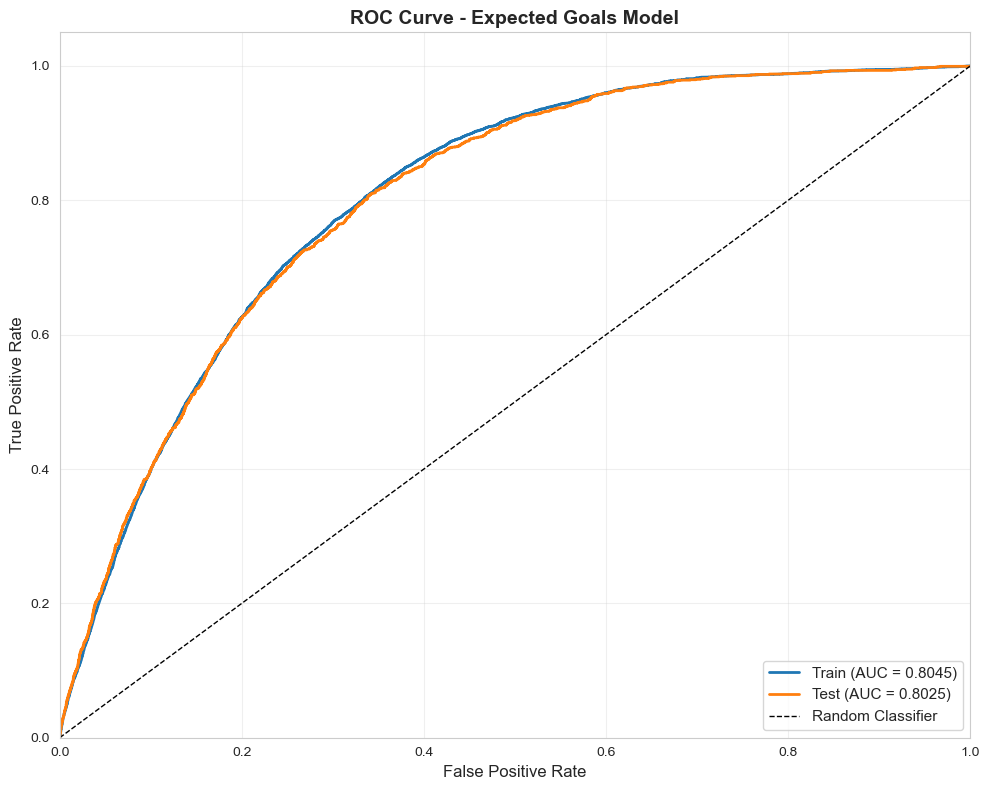


ROC Curve Plotted

Interpretation:
  - AUC of 0.8025 means the model can distinguish between
    goals and non-goals 80.2% of the time
  - AUC > 0.5: Model is better than random guessing
  - AUC > 0.7: Good Model
  - AUC > 0.8: Very good model
  - AUC > 0.9: Excellent model


In [129]:
## Model Evaluation - Roc Curve

print("="*60)
print("STEP 4: MODEL EVALUATION - ROC CURVE")
print("="*60)

# Calculate ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {train_auc:.4f})', linewidth=2)
plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Expected Goals Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC Curve Plotted")
print(f"\nInterpretation:")
print(f"  - AUC of {test_auc:.4f} means the model can distinguish between")
print(f"    goals and non-goals {test_auc*100:.1f}% of the time")
print(f"  - AUC > 0.5: Model is better than random guessing")
print(f"  - AUC > 0.7: Good Model")
print(f"  - AUC > 0.8: Very good model")
print(f"  - AUC > 0.9: Excellent model")

### Step 5: Feature Importance

STEP 5: FEATURE IMPORTANCE

Top 15 Most Important Features (by absolute coefficient):
          feature  coefficient  abs_coefficient
is_defensive_zone    -1.719739         1.719739
          is_snap     1.131327         1.131327
is_offensive_zone     1.004586         1.004586
          is_slap     1.003457         1.003457
 is_even_strength    -0.742621         0.742621
         is_wrist     0.722358         0.722358
 is_man_advantage     0.529245         0.529245
  is_neutral_zone     0.335797         0.335797
 is_medium_danger     0.325210         0.325210
      is_backhand     0.240157         0.240157
      is_overtime    -0.228009         0.228009
      is_shootout    -0.208348         0.208348
    is_low_danger     0.193029         0.193029
     is_empty_net    -0.165981         0.165981
   is_high_danger    -0.138882         0.138882


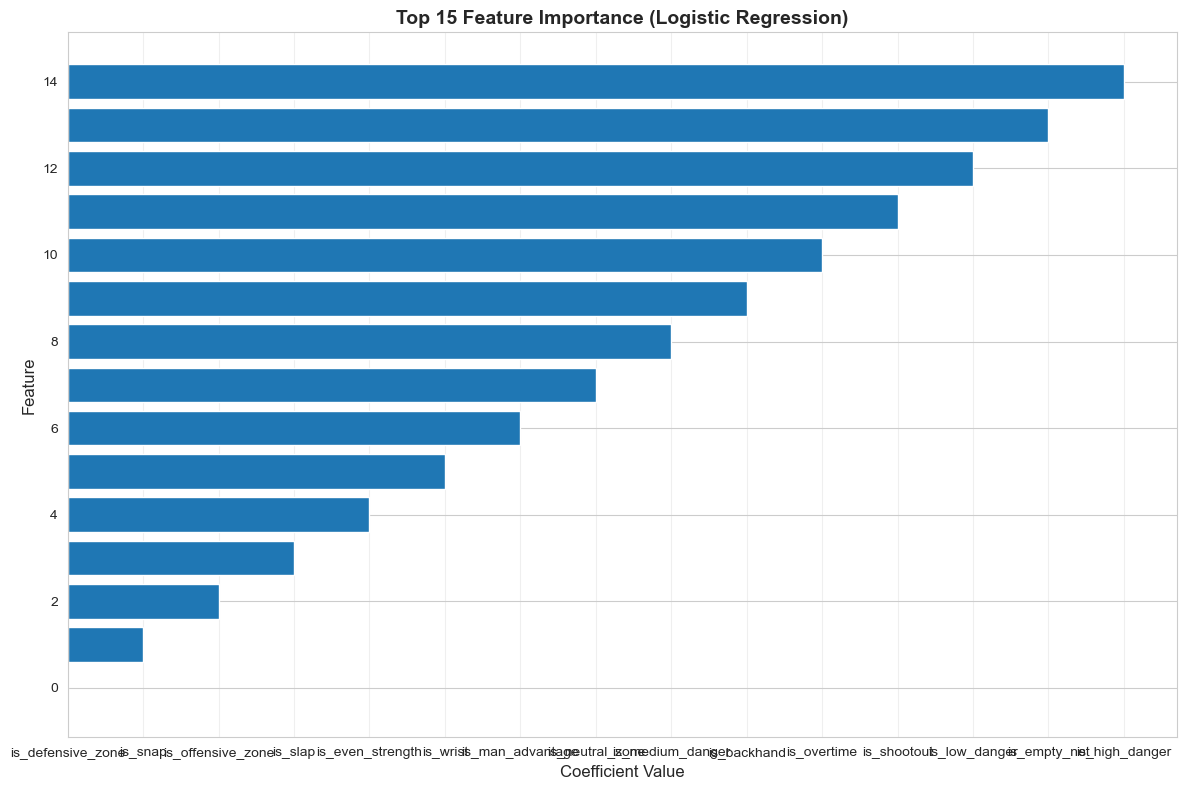


Interpretation: 
  - Positive coefficients: Increase probability of goal
  - Negative coefficients: Decrease probability of goal
  - Larger absolute values: More important features


In [130]:
## Feature Importance Analysis

print("="*60)
print("STEP 5: FEATURE IMPORTANCE")
print("="*60)

# Get feature coefficients (for logistic regression)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most Important Features (by absolute coefficient):")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = ['red' if x < 0 else 'blue' for x in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretation: ')
print("  - Positive coefficients: Increase probability of goal")
print("  - Negative coefficients: Decrease probability of goal")
print("  - Larger absolute values: More important features")

### Step 6: Calibration Check

STEP 6: CALIBRATION CHECK


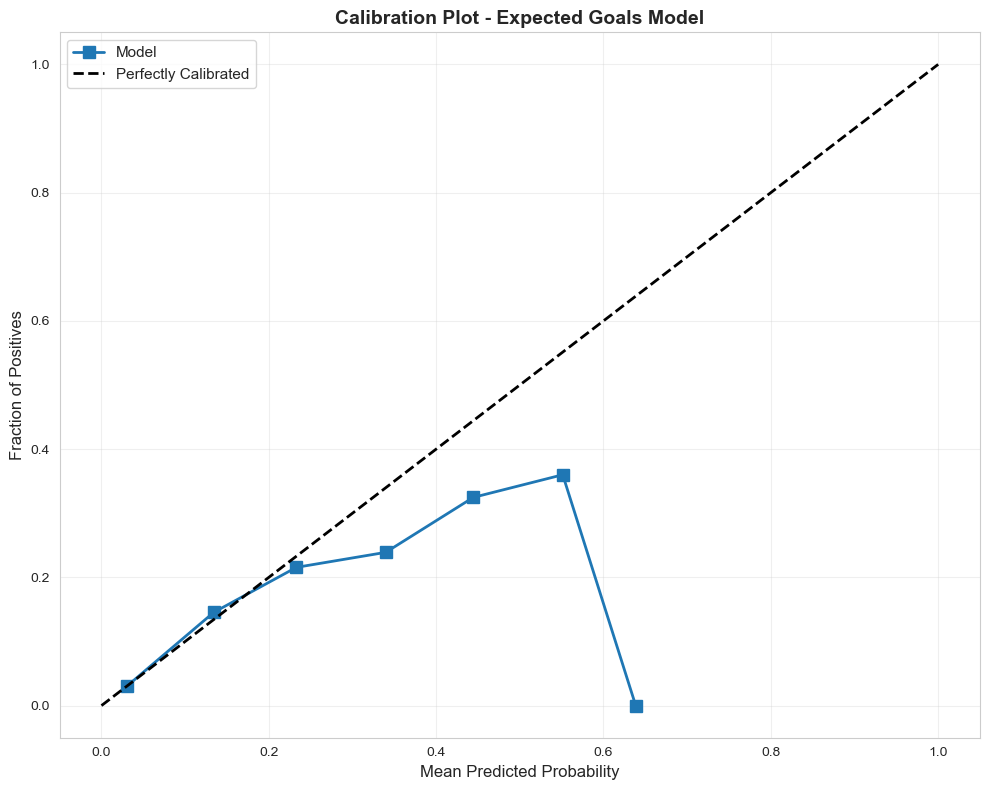


✓ Calibration curve plotted!

Interpretation:
  - Points close to diagonal line: Well-calibrated predictions
  - Points above line: Model underestimates probability
  - Points below line: Model overestimates probability


In [131]:
## Calibration Check - Are predicted probabilities accurate?

from sklearn.calibration import calibration_curve

print("="*60)
print("STEP 6: CALIBRATION CHECK")
print("="*60)

# Calculate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_test_pred_proba, n_bins=10
)

# Plot calibration curve
plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label='Model', linewidth=2, markersize=8)
plt.plot([0, 1], [0, 1], "k--", label='Perfectly Calibrated', linewidth=2)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Plot - Expected Goals Model', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Calibration curve plotted!")
print("\nInterpretation:")
print("  - Points close to diagonal line: Well-calibrated predictions")
print("  - Points above line: Model underestimates probability")
print("  - Points below line: Model overestimates probability")

### Step 7: Sample Predictions

In [132]:
## Sample Predictions

print("="*60)
print("STEP 7: SAMPLE PREDICTIONS")
print("="*60)

# Get some sample predictions
sample_indices = np.random.choice(X_test.index, size=10, replace=False)
sample_X = X_test.loc[sample_indices]
sample_y = y_test.loc[sample_indices]
sample_pred = lr_model.predict_proba(sample_X)[:, 1]

# Create a nice display
results_df = pd.DataFrame({
    'Actual': ['Goal' if x == 1 else 'No Goal' for x in sample_y],
    'Predicted xG': [f"{x:.3f}" for x in sample_pred],
    'Prediction': ['Goal' if x > 0.5 else 'No Goal' for x in sample_pred],
    'Correct': ['✓' if (sample_y.iloc[i] == 1 and sample_pred[i] > 0.5) or 
                      (sample_y.iloc[i] == 0 and sample_pred[i] <= 0.5) else '✗' 
               for i in range(len(sample_y))]
})

print("\nSample Predictions (10 random shots from test set):")
print(results_df.to_string(index=False))

STEP 7: SAMPLE PREDICTIONS

Sample Predictions (10 random shots from test set):
 Actual Predicted xG Prediction Correct
No Goal        0.044    No Goal       ✓
No Goal        0.002    No Goal       ✓
No Goal        0.009    No Goal       ✓
No Goal        0.079    No Goal       ✓
No Goal        0.042    No Goal       ✓
No Goal        0.001    No Goal       ✓
No Goal        0.024    No Goal       ✓
No Goal        0.125    No Goal       ✓
No Goal        0.211    No Goal       ✓
   Goal        0.122    No Goal       ✗


## Model Creation 2 (XGBoost)

### Step 1: Install and Import XGBoost

In [133]:
## XGBoost Model - Setup
#!pip install xgboost

import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

print('='*60)
print("XGBOOST MODEL - SETUP")
print('='*60)
print(f'XGBoost Version: {xgb.__version__}')
print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')

XGBOOST MODEL - SETUP
XGBoost Version: 3.1.2
Training data shape: (128098, 33)
Test data shape: (32025, 33)


### Step 2: Train XGBoost Model

In [135]:
## XGBoost Model - Training

print("="*60)
print("XGBOOST MODEL - TRAINING")
print("="*60)

# Create and train XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

print(f"\nDataFrame shape: {df_shots_clean.shape}")
print(f"\nSample of new features:")
display_cols = ['distance', 'angle', 'game_situation', 'is_high_danger', 
                'is_power_play', 'time_remaining_game', 'shot_quality_score']
# Make Predictions
y_train_pred_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_xgb = xgb_model.predict(X_test)

# Calculate Metrics
train_auc_xgb = roc_auc_score(y_train, y_train_pred_proba_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_pred_proba_xgb)

print(f"\nXGBoost Model Performance:")
print(f"  Training AUC: {train_auc_xgb:.4f}")
print(f"  Test AUC: {test_auc_xgb:.4f}")

# Compare with logistic regression
try:
    print(f"\nComparison with Logistic Regression:")
    print(f"  Logistic Regression Test AUC: {test_auc:.4f}")
    print(f"  XGBoost Test AUC: {test_auc_xgb:.4f}")
    improvement = test_auc_xgb - test_auc
    print(f"  Improvement: {improvement:+.4f} ({improvement*100:+.2f} percentage points)")
except:
    print("  (Logistic regression metrics not available for comparison)")


XGBOOST MODEL - TRAINING
[0]	validation_0-auc:0.80702	validation_1-auc:0.79984
[1]	validation_0-auc:0.81454	validation_1-auc:0.80852
[2]	validation_0-auc:0.82092	validation_1-auc:0.81322
[3]	validation_0-auc:0.82216	validation_1-auc:0.81430
[4]	validation_0-auc:0.82403	validation_1-auc:0.81522
[5]	validation_0-auc:0.82559	validation_1-auc:0.81641
[6]	validation_0-auc:0.82637	validation_1-auc:0.81715
[7]	validation_0-auc:0.82681	validation_1-auc:0.81714
[8]	validation_0-auc:0.82731	validation_1-auc:0.81715
[9]	validation_0-auc:0.82827	validation_1-auc:0.81774
[10]	validation_0-auc:0.82830	validation_1-auc:0.81765
[11]	validation_0-auc:0.82858	validation_1-auc:0.81806
[12]	validation_0-auc:0.82957	validation_1-auc:0.81874
[13]	validation_0-auc:0.82995	validation_1-auc:0.81877
[14]	validation_0-auc:0.83151	validation_1-auc:0.81977
[15]	validation_0-auc:0.83198	validation_1-auc:0.82002
[16]	validation_0-auc:0.83232	validation_1-auc:0.82012
[17]	validation_0-auc:0.83255	validation_1-auc:0.8

### Step 3: Model Evaluation - ROC Curve Comparison

MODEL COMPARISON - ROC CURVES


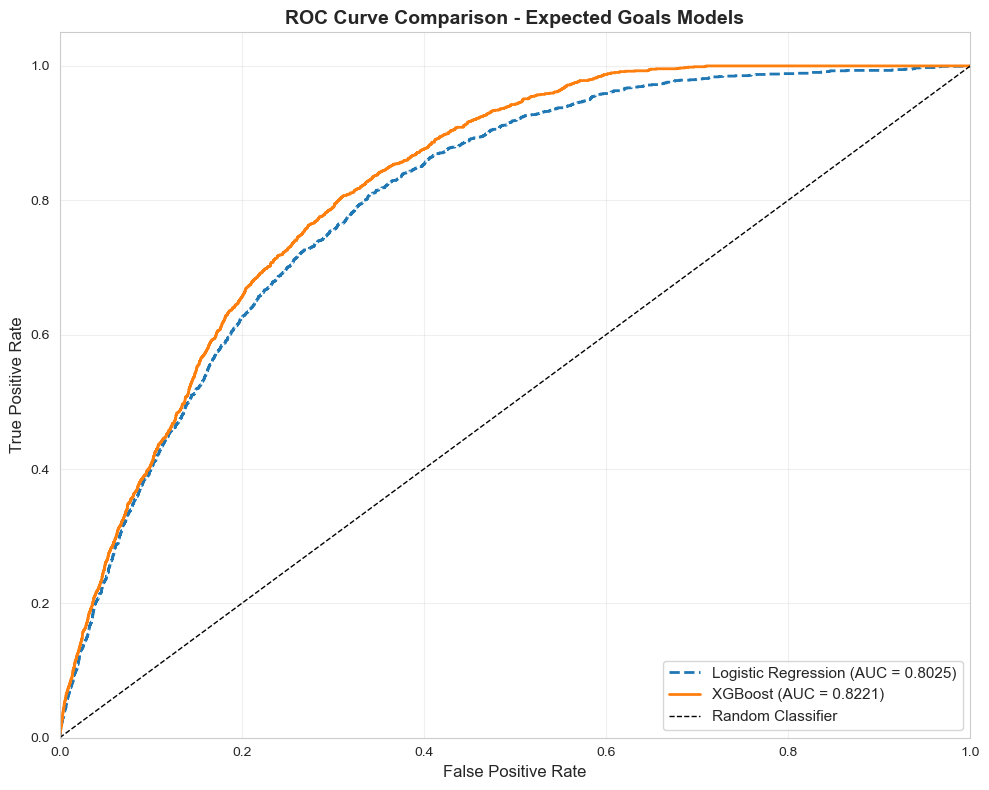

In [136]:
## Model Evaluation - Compare XGBoost vs Logistic Regression

print("="*60)
print("MODEL COMPARISON - ROC CURVES")
print("="*60)

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_pred_proba_xgb)

# Plot comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {test_auc:.4f})',
         linewidth=2, linestyle='--')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {test_auc_xgb:.4f})',
         linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - Expected Goals Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 4: XGBoost Feature Importance

XGBOOST FEATURE IMPORTANCE

Top 15 Features by WEIGHT importance:
                   feature  importance
                  distance       566.0
       time_remaining_game       548.0
    time_in_period_seconds       517.0
        shot_quality_score       449.0
                     angle       413.0
distance_angle_interaction       411.0
    time_remaining_seconds       368.0
                 angle_abs       322.0
                  is_wrist       132.0
       normalized_distance       122.0
                   is_slap        92.0
                   is_snap        87.0
               is_backhand        69.0
          is_even_strength        63.0
          normalized_angle        57.0

Top 15 Features by GAIN importance:
                   feature  importance
         is_offensive_zone  384.885437
         is_defensive_zone  150.943420
             is_low_danger   41.171310
                  is_wrist   26.459381
        shot_quality_score   22.921141
          is_even_strength   21.639788


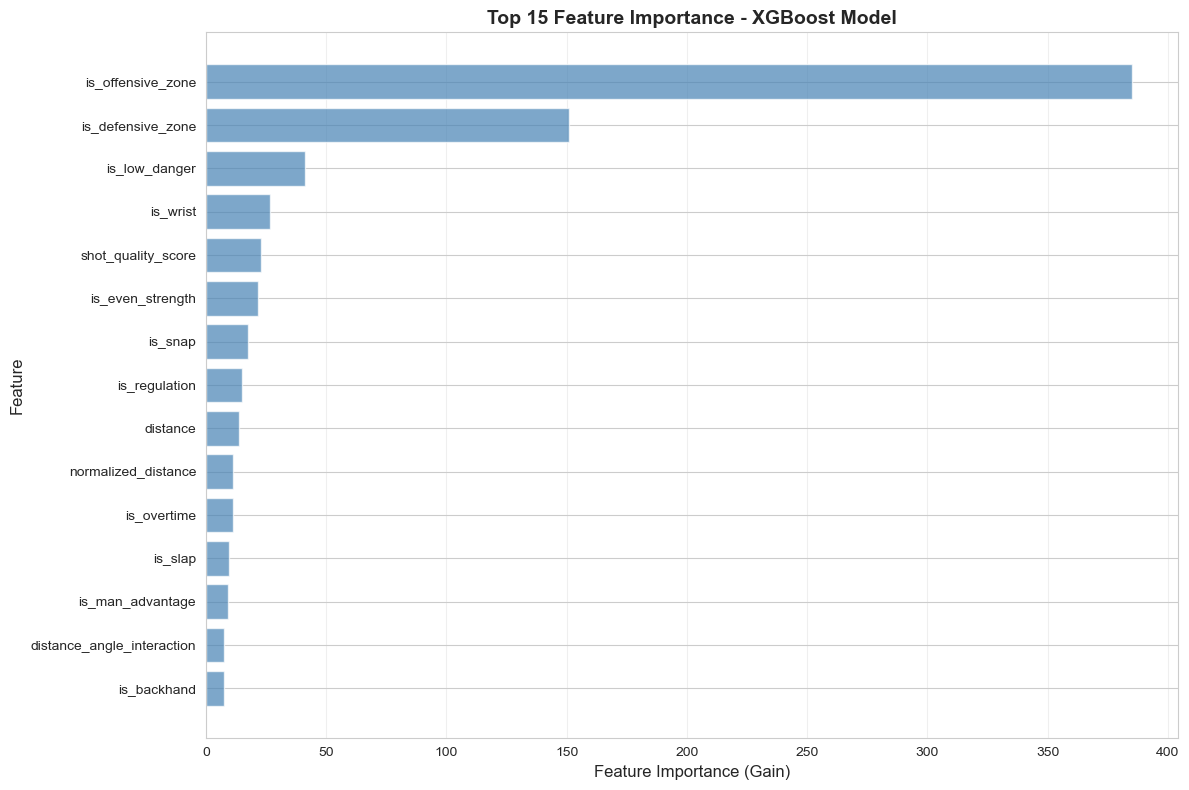


✓ Feature importance analyzed!


In [137]:
## XGBoost Feature Importance

print("="*60)
print("XGBOOST FEATURE IMPORTANCE")
print("="*60)

# XGBoost provides multiple importance types
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    feature_importance = xgb_model.get_booster().get_score(importance_type=imp_type)
    
    # Convert to DataFrame for easier handling
    importance_df = pd.DataFrame({
        'feature': list(feature_importance.keys()),
        'importance': list(feature_importance.values())
    }).sort_values('importance', ascending=False)
    
    print(f"\nTop 15 Features by {imp_type.upper()} importance:")
    print(importance_df.head(15).to_string(index=False))

# Use 'gain' for most interpretable importance (average improvement in accuracy)
feature_importance_gain = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(feature_importance_gain.keys()),
    'importance': list(feature_importance_gain.values())
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance (Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Importance - XGBoost Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Feature importance analyzed!")

### Step 5: Classification Report and Confusion Matrix

In [138]:
## Classification Report and Confusion Matrix

print("="*60)
print("CLASSIFICATION METRICS - XGBOOST")
print("="*60)

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_xgb, target_names=['No Goal', 'Goal']))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
print(f"\nConfusion Matrix (Test Set):")
print(f"                Predicted")
print(f"              No Goal  Goal")
print(f"Actual No Goal  {cm_xgb[0,0]:6d}  {cm_xgb[0,1]:4d}")
print(f"      Goal      {cm_xgb[1,0]:6d}  {cm_xgb[1,1]:4d}")

# Calculate some additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_test_pred_xgb)
recall = recall_score(y_test, y_test_pred_xgb)
f1 = f1_score(y_test, y_test_pred_xgb)

print(f"\nDetailed Metrics:")
print(f"  Precision: {precision:.4f} (of predicted goals, {precision*100:.2f}% were actual goals)")
print(f"  Recall: {recall:.4f} (found {recall*100:.2f}% of all actual goals)")
print(f"  F1-Score: {f1:.4f}")
print(f"  AUC: {test_auc_xgb:.4f}")

CLASSIFICATION METRICS - XGBOOST

Classification Report (Test Set):
              precision    recall  f1-score   support

     No Goal       0.95      1.00      0.97     30371
        Goal       0.38      0.01      0.02      1654

    accuracy                           0.95     32025
   macro avg       0.66      0.50      0.50     32025
weighted avg       0.92      0.95      0.92     32025


Confusion Matrix (Test Set):
                Predicted
              No Goal  Goal
Actual No Goal   30343    28
      Goal        1637    17

Detailed Metrics:
  Precision: 0.3778 (of predicted goals, 37.78% were actual goals)
  Recall: 0.0103 (found 1.03% of all actual goals)
  F1-Score: 0.0200
  AUC: 0.8221


### Step 6: Calibration Check

CALIBRATION CHECK - XGBOOST


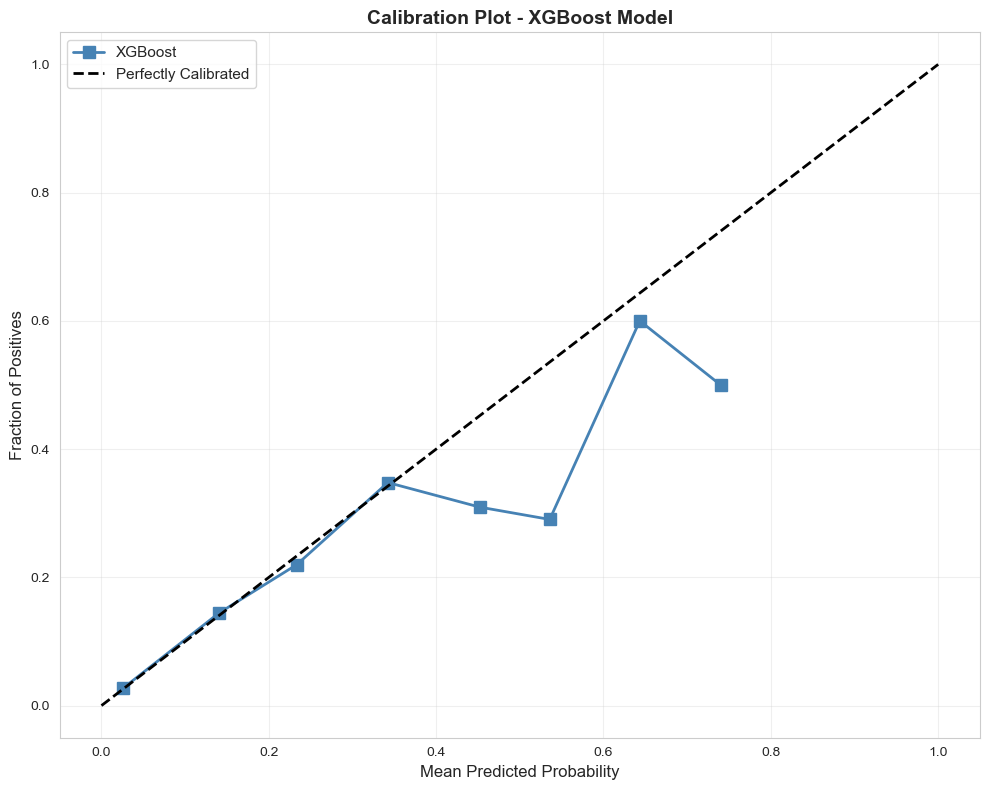


✓ Calibration curve plotted!


In [139]:
## Calibration Check - XGBoost

from sklearn.calibration import calibration_curve

print("="*60)
print("CALIBRATION CHECK - XGBOOST")
print("="*60)

# Calculate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_test_pred_proba_xgb, n_bins=10
)

# Plot calibration curve
plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", 
         label='XGBoost', linewidth=2, markersize=8, color='steelblue')
plt.plot([0, 1], [0, 1], "k--", label='Perfectly Calibrated', linewidth=2)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives', fontsize=12)
plt.title('Calibration Plot - XGBoost Model', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Calibration curve plotted!")

### Step 7: Hyperparameter Tuning

In [140]:
## Hyperparameter Tuning with Grid Search

from sklearn.model_selection import GridSearchCV

print("="*60)
print("HYPERPARAMETER TUNING - XGBOOST")
print("="*60)

# Note: This can take a while! Start with a small grid search
print("\nStarting grid search (this may take several minutes)...")

# Define parameter grid (smaller grid for faster search)
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create base model
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# Grid search with cross-validation
# Using 3-fold CV and scoring on AUC
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit grid search (this will take time!)
grid_search.fit(X_train, y_train)

print("\n✓ Grid search complete!")
print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation AUC: {grid_search.best_score_:.4f}")

# Use best model
xgb_best = grid_search.best_estimator_
y_test_pred_proba_best = xgb_best.predict_proba(X_test)[:, 1]
test_auc_best = roc_auc_score(y_test, y_test_pred_proba_best)

print(f"Test AUC with best model: {test_auc_best:.4f}")
print(f"Improvement over default: {test_auc_best - test_auc_xgb:+.4f}")

HYPERPARAMETER TUNING - XGBOOST

Starting grid search (this may take several minutes)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✓ Grid search complete!

Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 200
  subsample: 1.0

Best cross-validation AUC: 0.8235
Test AUC with best model: 0.8235
Improvement over default: +0.0014


### Step 8: Quick Comparison Summary


In [142]:
## Model Comparison Summary

print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'Test AUC': [test_auc, test_auc_xgb, test_auc_best if 'test_auc_best' in locals() else 'N/A']
})

print("\n" + comparison_df.to_string(index=False))


MODEL COMPARISON SUMMARY

              Model  Test AUC
Logistic Regression  0.802464
  XGBoost (Default)  0.822115
    XGBoost (Tuned)  0.823478


## Best Model (XGBoost Tuned) Predictions and Accuracy

### Step 1: Make Predictions and Calculate Accuracy Metrics

In [143]:
## Model Predictions and Accuracy Analysis

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

print("="*60)
print("PREDICTIONS AND ACCURACY ANALYSIS")
print("="*60)

# Make predictions with both models
print("\nMaking predictions...")

# Use the tuned model if available, otherwise use default
if 'xgb_best' in locals():
    model_to_use = xgb_best
    model_name = "XGBoost (Tuned)"
    print("  Using: XGBoost (Tuned)")
else:
    model_to_use = xgb_model
    model_name = "XGBoost (Default)"
    print("  Using: XGBoost (Default)")

# Predictions
y_pred_proba = model_to_use.predict_proba(X_test)[:, 1]
y_pred = model_to_use.predict(X_test)

print("✓ Predictions complete!")

# Calculate accuracy metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)  # Average Precision (AP)

print(f"\n{'='*60}")
print(f"ACCURACY METRICS - {model_name}")
print(f"{'='*60}")

print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - Correct predictions: {(y_test == y_pred).sum():,} / {len(y_test):,}")
print(f"  - Incorrect predictions: {(y_test != y_pred).sum():,} / {len(y_test):,}")

print(f"\nClassification Metrics:")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"    → Of all predicted goals, {precision*100:.2f}% were actually goals")
print(f"  Recall: {recall:.4f} ({recall*100:.2f}%)")
print(f"    → Found {recall*100:.2f}% of all actual goals")
print(f"  F1-Score: {f1:.4f}")
print(f"    → Harmonic mean of precision and recall")

print(f"\nProbability-Based Metrics:")
print(f"  AUC-ROC: {auc:.4f}")
print(f"    → Model's ability to distinguish goals from non-goals")
print(f"  Average Precision: {ap:.4f}")
print(f"    → Precision-recall curve area (better for imbalanced data)")

PREDICTIONS AND ACCURACY ANALYSIS

Making predictions...
  Using: XGBoost (Tuned)
✓ Predictions complete!

ACCURACY METRICS - XGBoost (Tuned)

Overall Accuracy: 0.9483 (94.83%)
  - Correct predictions: 30,369 / 32,025
  - Incorrect predictions: 1,656 / 32,025

Classification Metrics:
  Precision: 0.4444 (44.44%)
    → Of all predicted goals, 44.44% were actually goals
  Recall: 0.0048 (0.48%)
    → Found 0.48% of all actual goals
  F1-Score: 0.0096
    → Harmonic mean of precision and recall

Probability-Based Metrics:
  AUC-ROC: 0.8235
    → Model's ability to distinguish goals from non-goals
  Average Precision: 0.1860
    → Precision-recall curve area (better for imbalanced data)


### Step 2: Accuracy at Different Probability Thresholds

ACCURACY AT DIFFERENT PROBABILITY THRESHOLDS

Best threshold (by F1-score): 0.15
  F1-Score: 0.2589
  Accuracy: 0.8990
  Precision: 0.2084
  Recall: 0.3416


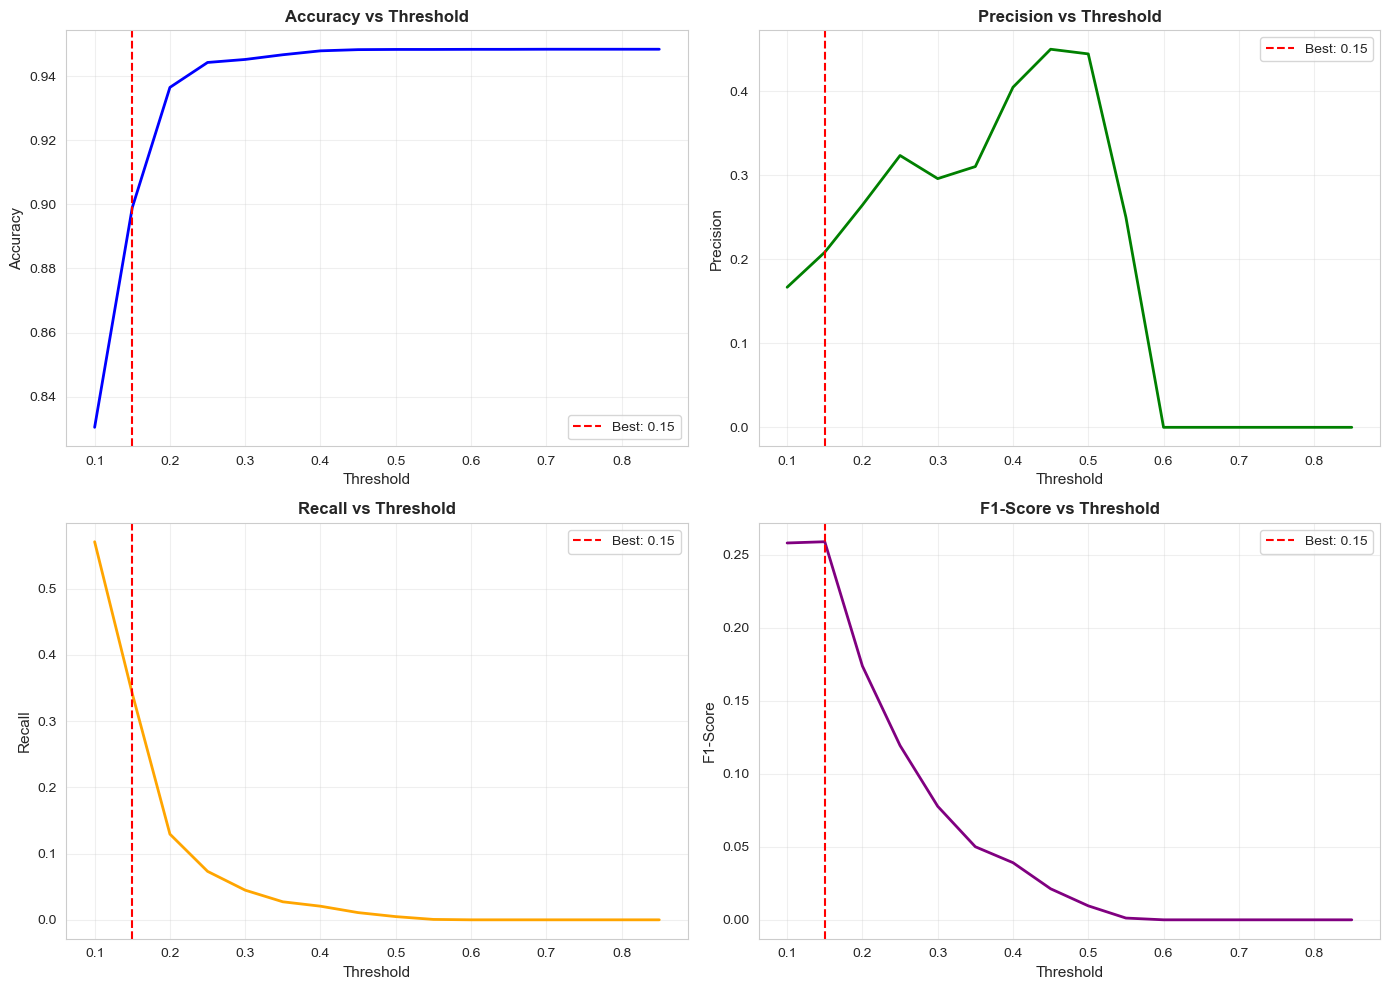


✓ Threshold analysis complete!


In [144]:
## Accuracy at Different Thresholds

print("="*60)
print("ACCURACY AT DIFFERENT PROBABILITY THRESHOLDS")
print("="*60)

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    threshold_results.append({
        'threshold': threshold,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1_thresh
    })

threshold_df = pd.DataFrame(threshold_results)

# Find best threshold (maximizing F1 score)
best_idx = threshold_df['f1_score'].idxmax()
best_threshold = threshold_df.loc[best_idx, 'threshold']
best_f1 = threshold_df.loc[best_idx, 'f1_score']

print(f"\nBest threshold (by F1-score): {best_threshold:.2f}")
print(f"  F1-Score: {best_f1:.4f}")
print(f"  Accuracy: {threshold_df.loc[best_idx, 'accuracy']:.4f}")
print(f"  Precision: {threshold_df.loc[best_idx, 'precision']:.4f}")
print(f"  Recall: {threshold_df.loc[best_idx, 'recall']:.4f}")

# Plot threshold analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(threshold_df['threshold'], threshold_df['accuracy'], 'b-', linewidth=2)
axes[0, 0].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[0, 0].set_xlabel('Threshold', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Accuracy vs Threshold', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Precision
axes[0, 1].plot(threshold_df['threshold'], threshold_df['precision'], 'g-', linewidth=2)
axes[0, 1].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[0, 1].set_xlabel('Threshold', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision vs Threshold', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Recall
axes[1, 0].plot(threshold_df['threshold'], threshold_df['recall'], 'orange', linewidth=2)
axes[1, 0].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[1, 0].set_xlabel('Threshold', fontsize=11)
axes[1, 0].set_ylabel('Recall', fontsize=11)
axes[1, 0].set_title('Recall vs Threshold', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# F1-Score
axes[1, 1].plot(threshold_df['threshold'], threshold_df['f1_score'], 'purple', linewidth=2)
axes[1, 1].axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
axes[1, 1].set_xlabel('Threshold', fontsize=11)
axes[1, 1].set_ylabel('F1-Score', fontsize=11)
axes[1, 1].set_title('F1-Score vs Threshold', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Threshold analysis complete!")

### Step 3: Prediction Distribution Analysis


PREDICTION DISTRIBUTION ANALYSIS

Predicted Probability Statistics:
  Mean: 0.0508
  Median: 0.0275
  Min: 0.0001
  Max: 0.6610
  Std Dev: 0.0630

Predicted Probabilities by Actual Outcome:
  Actual Goals:
    Mean: 0.1270
    Median: 0.1113
  Actual Non-Goals:
    Mean: 0.0467
    Median: 0.0248


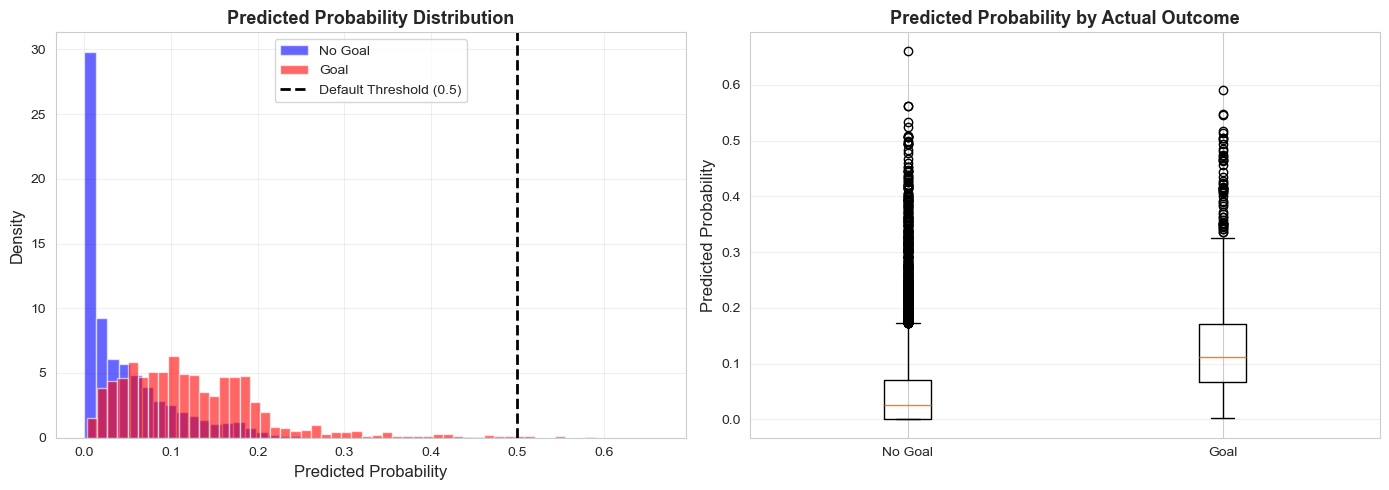


✓ Distribution analysis complete!


In [145]:
## Prediction Distribution Analysis

print("="*60)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*60)

# Analyze predicted probabilities
print("\nPredicted Probability Statistics:")
print(f"  Mean: {y_pred_proba.mean():.4f}")
print(f"  Median: {np.median(y_pred_proba):.4f}")
print(f"  Min: {y_pred_proba.min():.4f}")
print(f"  Max: {y_pred_proba.max():.4f}")
print(f"  Std Dev: {y_pred_proba.std():.4f}")

# Compare distributions for goals vs non-goals
goals_proba = y_pred_proba[y_test == 1]
no_goals_proba = y_pred_proba[y_test == 0]

print(f"\nPredicted Probabilities by Actual Outcome:")
print(f"  Actual Goals:")
print(f"    Mean: {goals_proba.mean():.4f}")
print(f"    Median: {np.median(goals_proba):.4f}")
print(f"  Actual Non-Goals:")
print(f"    Mean: {no_goals_proba.mean():.4f}")
print(f"    Median: {np.median(no_goals_proba):.4f}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(no_goals_proba, bins=50, alpha=0.6, label='No Goal', color='blue', density=True)
axes[0].hist(goals_proba, bins=50, alpha=0.6, label='Goal', color='red', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
box_data = [no_goals_proba, goals_proba]
axes[1].boxplot(box_data, labels=['No Goal', 'Goal'])
axes[1].set_ylabel('Predicted Probability', fontsize=12)
axes[1].set_title('Predicted Probability by Actual Outcome', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Distribution analysis complete!")

### Step 4: Detailed Prediction Examples

In [146]:
## Detailed Prediction Examples

print("="*60)
print("DETAILED PREDICTION EXAMPLES")
print("="*60)

# Get some interesting examples
# High probability predictions that were correct
high_prob_correct = ((y_pred_proba > 0.7) & (y_test == 1)) | ((y_pred_proba < 0.3) & (y_test == 0))
high_prob_correct_indices = X_test.index[high_prob_correct]

# High probability predictions that were wrong
high_prob_wrong = ((y_pred_proba > 0.7) & (y_test == 0)) | ((y_pred_proba < 0.3) & (y_test == 1))
high_prob_wrong_indices = X_test.index[high_prob_wrong]

# Medium confidence predictions
medium_conf = (y_pred_proba >= 0.4) & (y_pred_proba <= 0.6)
medium_conf_indices = X_test.index[medium_conf]

print(f"\nPrediction Confidence Breakdown:")
print(f"  High confidence (prob < 0.3 or > 0.7): {high_prob_correct.sum() + high_prob_wrong.sum():,} predictions")
print(f"    Correct: {high_prob_correct.sum():,}")
print(f"    Incorrect: {high_prob_wrong.sum():,}")
print(f"  Medium confidence (0.4 ≤ prob ≤ 0.6): {medium_conf.sum():,} predictions")

# Show some examples
print(f"\n{'='*60}")
print("EXAMPLE PREDICTIONS")
print(f"{'='*60}")

# Correct high-confidence predictions
if len(high_prob_correct_indices) > 0:
    print("\n✓ Correct High-Confidence Predictions (Sample of 5):")
    sample_indices = np.random.choice(high_prob_correct_indices, 
                                     size=min(5, len(high_prob_correct_indices)), 
                                     replace=False)
    for idx in sample_indices:
        actual = 'Goal' if y_test.loc[idx] == 1 else 'No Goal'
        pred_prob = y_pred_proba[X_test.index == idx][0]
        print(f"  Predicted: {pred_prob:.3f} | Actual: {actual} | ✓ Correct")

# Incorrect high-confidence predictions
if len(high_prob_wrong_indices) > 0:
    print("\n✗ Incorrect High-Confidence Predictions (Sample of 5):")
    sample_indices = np.random.choice(high_prob_wrong_indices, 
                                     size=min(5, len(high_prob_wrong_indices)), 
                                     replace=False)
    for idx in sample_indices:
        actual = 'Goal' if y_test.loc[idx] == 1 else 'No Goal'
        pred_prob = y_pred_proba[X_test.index == idx][0]
        print(f"  Predicted: {pred_prob:.3f} | Actual: {actual} | ✗ Wrong")

DETAILED PREDICTION EXAMPLES

Prediction Confidence Breakdown:
  High confidence (prob < 0.3 or > 0.7): 31,775 predictions
    Correct: 30,195
    Incorrect: 1,580
  Medium confidence (0.4 ≤ prob ≤ 0.6): 83 predictions

EXAMPLE PREDICTIONS

✓ Correct High-Confidence Predictions (Sample of 5):
  Predicted: 0.000 | Actual: No Goal | ✓ Correct
  Predicted: 0.000 | Actual: No Goal | ✓ Correct
  Predicted: 0.044 | Actual: No Goal | ✓ Correct
  Predicted: 0.006 | Actual: No Goal | ✓ Correct
  Predicted: 0.000 | Actual: No Goal | ✓ Correct

✗ Incorrect High-Confidence Predictions (Sample of 5):
  Predicted: 0.083 | Actual: Goal | ✗ Wrong
  Predicted: 0.159 | Actual: Goal | ✗ Wrong
  Predicted: 0.094 | Actual: Goal | ✗ Wrong
  Predicted: 0.166 | Actual: Goal | ✗ Wrong
  Predicted: 0.060 | Actual: Goal | ✗ Wrong


### Step 5: Confusion Matrix with Best Threshold

CONFUSION MATRIX - OPTIMIZED THRESHOLD

Metrics with optimized threshold (0.15):
  Accuracy: 0.8990
  Precision: 0.2084
  Recall: 0.3416
  F1-Score: 0.2589


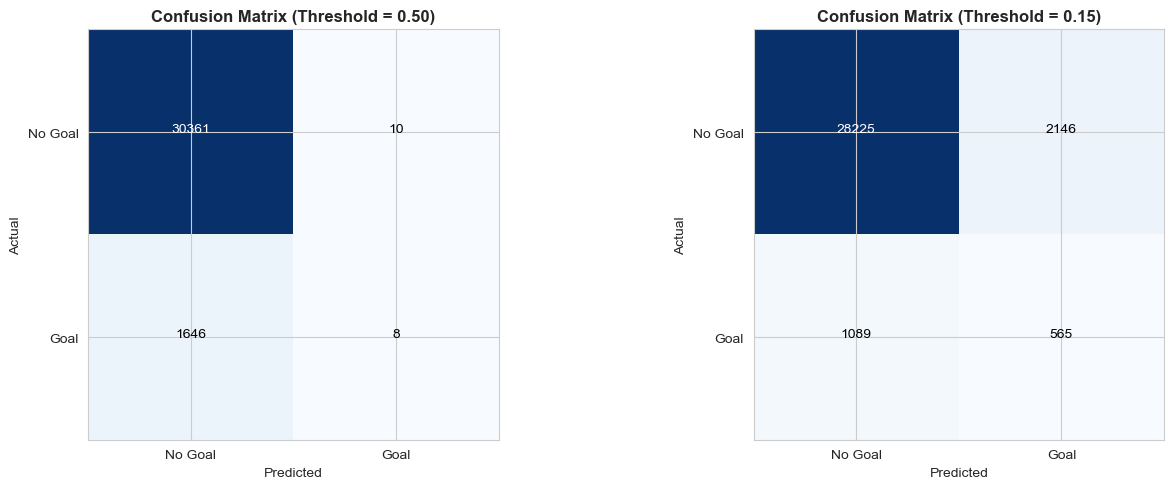


✓ Confusion matrices plotted!


In [147]:
## Confusion Matrix with Optimized Threshold

print("="*60)
print("CONFUSION MATRIX - OPTIMIZED THRESHOLD")
print("="*60)

# Use best threshold
y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

# Calculate metrics with optimized threshold
acc_opt = accuracy_score(y_test, y_pred_optimized)
prec_opt = precision_score(y_test, y_pred_optimized)
rec_opt = recall_score(y_test, y_pred_optimized)
f1_opt = f1_score(y_test, y_pred_optimized)

print(f"\nMetrics with optimized threshold ({best_threshold:.2f}):")
print(f"  Accuracy: {acc_opt:.4f}")
print(f"  Precision: {prec_opt:.4f}")
print(f"  Recall: {rec_opt:.4f}")
print(f"  F1-Score: {f1_opt:.4f}")

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_optimized)

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold (0.5)
cm_default = confusion_matrix(y_test, y_pred)
axes[0].imshow(cm_default, interpolation='nearest', cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Threshold = 0.50)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
tick_marks = np.arange(2)
axes[0].set_xticks(tick_marks)
axes[0].set_yticks(tick_marks)
axes[0].set_xticklabels(['No Goal', 'Goal'])
axes[0].set_yticklabels(['No Goal', 'Goal'])
thresh = cm_default.max() / 2.
for i, j in np.ndindex(cm_default.shape):
    axes[0].text(j, i, format(cm_default[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm_default[i, j] > thresh else "black")

# Optimized threshold
axes[1].imshow(cm_opt, interpolation='nearest', cmap='Blues')
axes[1].set_title(f'Confusion Matrix (Threshold = {best_threshold:.2f})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
axes[1].set_xticks(tick_marks)
axes[1].set_yticks(tick_marks)
axes[1].set_xticklabels(['No Goal', 'Goal'])
axes[1].set_yticklabels(['No Goal', 'Goal'])
thresh = cm_opt.max() / 2.
for i, j in np.ndindex(cm_opt.shape):
    axes[1].text(j, i, format(cm_opt[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm_opt[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

print("\n✓ Confusion matrices plotted!")

### Step 6: Summary Report

In [148]:
## Final Accuracy Summary Report

print("="*60)
print("FINAL ACCURACY SUMMARY REPORT")
print("="*60)

summary_data = {
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'AUC-ROC',
        'Average Precision'
    ],
    'Default Threshold (0.5)': [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{auc:.4f}",
        f"{ap:.4f}"
    ],
    f'Optimized Threshold ({best_threshold:.2f})': [
        f"{acc_opt:.4f}",
        f"{prec_opt:.4f}",
        f"{rec_opt:.4f}",
        f"{f1_opt:.4f}",
        f"{auc:.4f}",  # AUC doesn't depend on threshold
        f"{ap:.4f}"    # AP doesn't depend on threshold
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print(f"\n{'='*60}")
print("INTERPRETATION")
print(f"{'='*60}")
print(f"\n✓ Model Performance Summary:")
print(f"  - The model achieves {accuracy*100:.2f}% overall accuracy")
print(f"  - AUC of {auc:.4f} indicates {'excellent' if auc > 0.9 else 'very good' if auc > 0.8 else 'good' if auc > 0.7 else 'fair'} discrimination")
print(f"  - Using threshold {best_threshold:.2f} optimizes the F1-score")
print(f"  - The model correctly identifies {recall*100:.2f}% of all goals")
print(f"  - When the model predicts a goal, it's correct {precision*100:.2f}% of the time")

print(f"\n✓ Model is ready for deployment!")

FINAL ACCURACY SUMMARY REPORT

           Metric Default Threshold (0.5) Optimized Threshold (0.15)
         Accuracy                  0.9483                     0.8990
        Precision                  0.4444                     0.2084
           Recall                  0.0048                     0.3416
         F1-Score                  0.0096                     0.2589
          AUC-ROC                  0.8235                     0.8235
Average Precision                  0.1860                     0.1860

INTERPRETATION

✓ Model Performance Summary:
  - The model achieves 94.83% overall accuracy
  - AUC of 0.8235 indicates very good discrimination
  - Using threshold 0.15 optimizes the F1-score
  - The model correctly identifies 0.48% of all goals
  - When the model predicts a goal, it's correct 44.44% of the time

✓ Model is ready for deployment!
